# Analysis of Seymour (L1 larva) synapses

In [2]:
import pandas as pd
import numpy as np


### Load the connector information

In [57]:
# load all connector ids
connectors_df=pd.read_csv('/Users/sam/Library/CloudStorage/OneDrive-UniversityofCambridge/Synapse_localisation/synapse_curation/data/seymour_synapses/axon_dendrite_connectors_withNeuropilsCellTypesAndLineages.csv')
print(connectors_df.columns)
display(connectors_df.head())


Index(['connector_id', 'presynaptic_neuron', 'presynaptic_neuron_node', 'x',
       'y', 'z', 'postsynaptic_neuron', 'postsynaptic_neuron_node',
       'presynaptic_type', 'postsynaptic_type', 'in_subgraph',
       'compartment_type', 'neuropil', 'side', 'presynaptic_neuron_type',
       'postsynaptic_neuron_type', 'presynaptic_neuron_lineage',
       'postsynaptic_neuron_lineage', 'presynaptic_neuron_level_7_cluster',
       'postsynaptic_neuron_level_7_cluster'],
      dtype='object')


,connector_id,presynaptic_neuron,presynaptic_neuron_node,x,y,z,postsynaptic_neuron,postsynaptic_neuron_node,presynaptic_type,postsynaptic_type,in_subgraph,compartment_type,neuropil,side,presynaptic_neuron_type,postsynaptic_neuron_type,presynaptic_neuron_lineage,postsynaptic_neuron_lineage,presynaptic_neuron_level_7_cluster,postsynaptic_neuron_level_7_cluster
0,396,29.0,384.0,26664.6,31346.2,46850.0,8419602.0,404.0,axon,axon,True,aa,MB-IP,Right,KC,KC,MB AM_R,MB AM_R,42.0,42.0
1,396,29.0,384.0,26664.6,31346.2,46850.0,9469519.0,9470642.0,axon,dendrite,True,ad,MB-IP,Right,KC,MBON,MB AM_R,BLVa3/4 a_R,42.0,59.0
2,396,29.0,384.0,26664.6,31346.2,46850.0,8419602.0,10527327.0,axon,axon,True,aa,MB-IP,Right,KC,KC,MB AM_R,MB AM_R,42.0,42.0
3,8257,3071301.0,8254.0,46800.8,63517.0,57800.0,8267.0,8271.0,axon,NaN,False,a-,NaN,NaN,MxN-sens,NaN,NaN,NaN,4.0,NaN
4,8257,3071301.0,8254.0,46800.8,63517.0,57800.0,8275.0,8279.0,axon,NaN,False,a-,NaN,NaN,MxN-sens,NaN,NaN,NaN,4.0,NaN


In [77]:
# Group by connector_id and count the number of unique presynaptic and postsynaptic partners
connector_group = connectors_df.groupby('connector_id').agg(
    num_pres=('presynaptic_neuron', 'nunique'),
    num_posts=('postsynaptic_neuron', 'nunique')
).reset_index()

# Display the first few rows of the result
display(connector_group.head())

# Display the maximum number of presynaptic partners
max_pres = connector_group['num_pres'].max()
print(f"Maximum number of presynaptic partners: {max_pres}")

# Display the maximum number of postsynaptic partners
max_posts = connector_group['num_posts'].max()
print(f"Maximum number of postsynaptic partners: {max_posts}")

# Display the number of connectors with more than 1 presynaptic partner
num_multi_pres = (connector_group['num_pres'] > 1).sum()
print(f"Number of connectors with more than 1 presynaptic partner: {num_multi_pres}")

# Display the number of connectors with more than 1 postsynaptic partner
num_multi_posts = (connector_group['num_posts'] > 1).sum()
print(f"Number of connectors with more than 1 postsynaptic partner: {num_multi_posts}")
print(f"Pct of connectors with more than 1 postsynaptic partner: {round(num_multi_posts/connector_group.shape[0], 3)*100}%")

# Display the number of unique connector ids
num_connectors = connector_group.shape[0]
print(f"Number of unique connector ids: {num_connectors}")

# Display the number of unique presynaptic neurons
num_presynaptic_neurons = connectors_df['presynaptic_neuron'].nunique()
print(f"Number of unique presynaptic neurons: {num_presynaptic_neurons}")

# Display the number of unique postsynaptic neurons
num_postsynaptic_neurons = connectors_df['postsynaptic_neuron'].nunique()
print(f"Number of unique postsynaptic neurons: {num_postsynaptic_neurons}")

,connector_id,num_pres,num_posts
0,396,1,2
1,8257,1,4
2,8661,1,4
3,8695,1,6
4,9344,1,6


Maximum number of presynaptic partners: 1
Maximum number of postsynaptic partners: 25
Number of connectors with more than 1 presynaptic partner: 0
Number of connectors with more than 1 postsynaptic partner: 210911
Pct of connectors with more than 1 postsynaptic partner: 95.5%
Number of unique connector ids: 220868
Number of unique presynaptic neurons: 14001
Number of unique postsynaptic neurons: 330358


### Make pymaid connection

In [80]:
import pymaid
url = "https://neurophyla.mrc-lmb.cam.ac.uk/catmaid/drosophila/l1/seymour/"
token = "4262617973671ba819a6aa86a5f5b5b311539f77"
name = "smohinta"
password = "headset-recovery-handshake"
project_id = 1
rm = pymaid.CatmaidInstance(url, token, name, password, project_id=project_id)


INFO  : Global CATMAID instance set. Caching is ON. (pymaid)


In [75]:
# check size of df prior
print(f"shape of connectors df: {connectors_df.shape}")
# check unique pre and post neurons
print(f'num unique pre-syns: {connectors_df["presynaptic_neuron"].nunique()}')
print(f'num of unique post-syns: {connectors_df["postsynaptic_neuron"].nunique()}')
# drop nans before making a list of ids and fetching connector info with locations
pres = connectors_df["presynaptic_neuron"].dropna().astype(int).unique().tolist()
post = connectors_df["postsynaptic_neuron"].dropna().astype(int).unique().tolist()
print(f'num of pre-syns after dropping nans: {len(pres)}')
print(f'num of post-syns after dropping nans: {len(post)}')


shape of connectors df: (872381, 20)
num unique pre-syns: 14001
num of unique post-syns: 330358
num of pre-syns after dropping nans: 14001
num of post-syns after dropping nans: 330358


In [88]:
from tqdm import tqdm
import os
batch_size = 1000  # Define the batch size
num_batches = len(pres) // batch_size + 1
print(f"num batches: {num_batches}")
output_dir = '/Users/sam/Library/CloudStorage/OneDrive-UniversityofCambridge/Synapse_localisation/synapse_curation/data/seymour_synapses/connectors_batch_processed'
os.makedirs(output_dir, exist_ok=True)
# if a connectors_batch_processed file has not been created, create one. This is expensive so only do it once!
# Open a CSV file to write the results
with open(os.path.join(output_dir,'connectors_batch_processed.csv'), 'w') as f:
    for i in tqdm(range(num_batches), desc='Processing batches', total=num_batches):
        batch_pres = pres[i * batch_size:(i + 1) * batch_size]
        batch_post = post[i * batch_size:(i + 1) * batch_size]
        
        # Fetch connectors for the current batch
        batch_connectors = pymaid.get_connectors_between(batch_pres, batch_post, remote_instance=rm)
        print(batch_connectors)
        
        # Convert the batch connectors to a DataFrame
        batch_connectors_df = pd.DataFrame(batch_connectors)
        
        # Write the batch to the CSV file
        if i == 0:
            batch_connectors_df.to_csv(f, index=False)
        else:
            batch_connectors_df.to_csv(f, index=False, header=False, mode='a')



num batches: 15


Processing batches:   0%|          | 0/15 [00:00<?, ?it/s]INFO  : Cached data used. Use `pymaid.clear_cache()` to clear. (pymaid)
INFO  : Cached data used. Use `pymaid.clear_cache()` to clear. (pymaid)
Processing batches:   7%|▋         | 1/15 [00:00<00:05,  2.38it/s]INFO  : Cached data used. Use `pymaid.clear_cache()` to clear. (pymaid)
INFO  : Cached data used. Use `pymaid.clear_cache()` to clear. (pymaid)


       connector_id                   connector_loc  node1_id  source_neuron  \
0               396     [26664.6, 31346.2, 46850.0]       384             29   
1               396     [26664.6, 31346.2, 46850.0]       384             29   
2               396     [26664.6, 31346.2, 46850.0]       384             29   
3              8257     [46800.8, 63517.0, 57800.0]      8254        3071301   
4              8257     [46800.8, 63517.0, 57800.0]      8254        3071301   
...             ...                             ...       ...            ...   
22914      63941001  [66957.92, 83257.46, 158400.0]    689660         689215   
22915      16984196     [65633.6, 86442.4, 91100.0]  16984198         471705   
22916      16984196     [65633.6, 86442.4, 91100.0]  16984198         471705   
22917      63162630  [49848.14, 78298.53, 157200.0]  63162629       22190714   
22918        462293    [50498.2, 78481.4, 158550.0]    462290       22190714   

       confidence1     creator1        

Processing batches:  13%|█▎        | 2/15 [00:00<00:03,  4.19it/s]INFO  : Cached data used. Use `pymaid.clear_cache()` to clear. (pymaid)
INFO  : Cached data used. Use `pymaid.clear_cache()` to clear. (pymaid)
INFO  : Cached data used. Use `pymaid.clear_cache()` to clear. (pymaid)
INFO  : Cached data used. Use `pymaid.clear_cache()` to clear. (pymaid)
Processing batches:  27%|██▋       | 4/15 [00:00<00:01,  8.20it/s]INFO  : Cached data used. Use `pymaid.clear_cache()` to clear. (pymaid)
INFO  : Cached data used. Use `pymaid.clear_cache()` to clear. (pymaid)
INFO  : Cached data used. Use `pymaid.clear_cache()` to clear. (pymaid)
INFO  : Cached data used. Use `pymaid.clear_cache()` to clear. (pymaid)
INFO  : Cached data used. Use `pymaid.clear_cache()` to clear. (pymaid)
INFO  : Cached data used. Use `pymaid.clear_cache()` to clear. (pymaid)
Processing batches:  47%|████▋     | 7/15 [00:00<00:00, 12.73it/s]INFO  : Cached data used. Use `pymaid.clear_cache()` to clear. (pymaid)
INFO  : Ca

      connector_id                 connector_loc  node1_id  source_neuron  \
0          7172467  [49810.4, 78946.9, 153000.0]   7172474         224633   
1          7179895  [50426.0, 78561.2, 153250.0]   7179901         224633   
2          7179895  [50426.0, 78561.2, 153250.0]   7179901         224633   
3          6042282  [52812.4, 78682.8, 153500.0]   6042288         224633   
4          1465744  [66807.8, 83045.2, 161550.0]   1465741         224633   
...            ...                           ...       ...            ...   
3052       3796620   [55730.8, 71850.4, 57000.0]   3796626       21863551   
3053       3795825   [52272.8, 72538.2, 58500.0]   3795831       21863551   
3054       3795782   [52310.8, 72276.0, 58300.0]   3795788       21863551   
3055       3664574  [60212.9, 76026.6, 138950.0]   3664581       22209402   
3056       3664397  [59730.3, 76281.2, 138800.0]   3664403       22209402   

      confidence1  creator1                     node1_loc  node2_id  \
0   

INFO  : Cached data used. Use `pymaid.clear_cache()` to clear. (pymaid)
INFO  : Cached data used. Use `pymaid.clear_cache()` to clear. (pymaid)
INFO  : Cached data used. Use `pymaid.clear_cache()` to clear. (pymaid)
INFO  : Cached data used. Use `pymaid.clear_cache()` to clear. (pymaid)
INFO  : Cached data used. Use `pymaid.clear_cache()` to clear. (pymaid)
INFO  : Cached data used. Use `pymaid.clear_cache()` to clear. (pymaid)
Processing batches:  73%|███████▎  | 11/15 [00:00<00:00, 18.40it/s]INFO  : Cached data used. Use `pymaid.clear_cache()` to clear. (pymaid)
INFO  : Cached data used. Use `pymaid.clear_cache()` to clear. (pymaid)
INFO  : Cached data used. Use `pymaid.clear_cache()` to clear. (pymaid)
INFO  : Cached data used. Use `pymaid.clear_cache()` to clear. (pymaid)
INFO  : Cached data used. Use `pymaid.clear_cache()` to clear. (pymaid)
INFO  : Cached data used. Use `pymaid.clear_cache()` to clear. (pymaid)
INFO  : Cached data used. Use `pymaid.clear_cache()` to clear. (pymai

     connector_id                    connector_loc  node1_id  source_neuron  \
0          795665      [54096.8, 66644.4, 68700.0]    414513         794518   
1        19036061    [73878.27, 33315.46, 36800.0]  19036064       16664111   
2        22224669      [62061.6, 73138.6, 66200.0]    414045         794518   
3         5280056      [47530.4, 64695.0, 67450.0]   5280062       20206971   
4        22950018  [43587.684, 64300.137, 63150.0]  22950011       17389577   
..            ...                              ...       ...            ...   
576      63372011    [82961.5, 28021.082, 55050.0]  63372008       17728896   
577      20294797      [40047.4, 59721.4, 67150.0]  20294796       18695745   
578      20294820      [40541.4, 60401.6, 67850.0]  20294819       18695745   
579      63425787   [39099.016, 58031.65, 68200.0]  19668738       16546021   
580      63426331   [42252.27, 72889.68, 209050.0]  63426332       18830521   

     confidence1  creator1                        n

In [89]:
# Read the batched CSV file
import os
output_dir = '/Users/sam/Library/CloudStorage/OneDrive-UniversityofCambridge/Synapse_localisation/synapse_curation/data/seymour_synapses/connectors_batch_processed'
batched_connectors_df = pd.read_csv(os.path.join(output_dir, 'connectors_batch_processed.csv'))

# Display the first few rows
display(batched_connectors_df.head())

,connector_id,connector_loc,node1_id,source_neuron,confidence1,creator1,node1_loc,node2_id,target_neuron,confidence2,creator2,node2_loc
0,396,"[26664.6, 31346.2, 46850.0]",384,29,5,albert,"[26759.6, 31334.8, 46950.0]",10527327,8419602,5,kathi,"[26142.1, 31935.2, 46850.0]"
1,396,"[26664.6, 31346.2, 46850.0]",384,29,5,albert,"[26759.6, 31334.8, 46950.0]",404,8419602,5,albert,"[26482.2, 31304.4, 46850.0]"
2,396,"[26664.6, 31346.2, 46850.0]",384,29,5,albert,"[26759.6, 31334.8, 46950.0]",9470642,9469519,5,albert,"[26406.2, 31496.3, 46850.0]"
3,8257,"[46800.8, 63517.0, 57800.0]",8254,3071301,5,caseysm,"[46557.6, 63262.4, 57800.0]",8279,8275,5,caseysm,"[46838.8, 63870.4, 57750.0]"
4,8257,"[46800.8, 63517.0, 57800.0]",8254,3071301,5,caseysm,"[46557.6, 63262.4, 57800.0]",8271,8267,5,caseysm,"[46702.0, 63900.8, 57750.0]"


In [90]:
# Expand locations into x,y and z and rename attributes of dataframe for clarity 
batched_connectors_df[['connector_x', 'connector_y', 'connector_z']] = pd.DataFrame(batched_connectors_df['connector_loc'].apply(eval).tolist(), index=batched_connectors_df.index)
batched_connectors_df[['pre_x', 'pre_y', 'pre_z']] = pd.DataFrame(batched_connectors_df['node1_loc'].apply(eval).tolist(), index=batched_connectors_df.index)
batched_connectors_df[['post_x', 'post_y', 'post_z']] = pd.DataFrame(batched_connectors_df['node2_loc'].apply(eval).tolist(), index=batched_connectors_df.index)
batched_connectors_df.rename(columns={
    'node1_id': 'prenode_id',
    'source_neuron': 'pre_neuron',
    'node2_id': 'postnode_id',
    'target_neuron': 'post_neuron'
}, inplace=True)
df = batched_connectors_df.drop(columns=['creator1','creator2','connector_loc','node1_loc','node2_loc'])
df.to_csv(os.path.join(output_dir,'connectors_parsed.csv'))
display(df.head())


,connector_id,prenode_id,pre_neuron,confidence1,postnode_id,post_neuron,confidence2,connector_x,connector_y,connector_z,pre_x,pre_y,pre_z,post_x,post_y,post_z
0,396,384,29,5,10527327,8419602,5,26664.6,31346.2,46850.0,26759.6,31334.8,46950.0,26142.1,31935.2,46850.0
1,396,384,29,5,404,8419602,5,26664.6,31346.2,46850.0,26759.6,31334.8,46950.0,26482.2,31304.4,46850.0
2,396,384,29,5,9470642,9469519,5,26664.6,31346.2,46850.0,26759.6,31334.8,46950.0,26406.2,31496.3,46850.0
3,8257,8254,3071301,5,8279,8275,5,46800.8,63517.0,57800.0,46557.6,63262.4,57800.0,46838.8,63870.4,57750.0
4,8257,8254,3071301,5,8271,8267,5,46800.8,63517.0,57800.0,46557.6,63262.4,57800.0,46702.0,63900.8,57750.0


In [118]:
# load connectors_parsed.csv
df=pd.read_csv('/Users/sam/Library/CloudStorage/OneDrive-UniversityofCambridge/Synapse_localisation/synapse_curation/data/seymour_synapses/connectors_batch_processed/connectors_parsed.csv')

# check the shape of the dataframe
print(df.shape)

# check for duplicates
print(df.duplicated().sum())



(42115, 17)
0


Mean: 1.4
Median: 1.0
Mode: 1.0
Min: 1.0
Max: 15.0


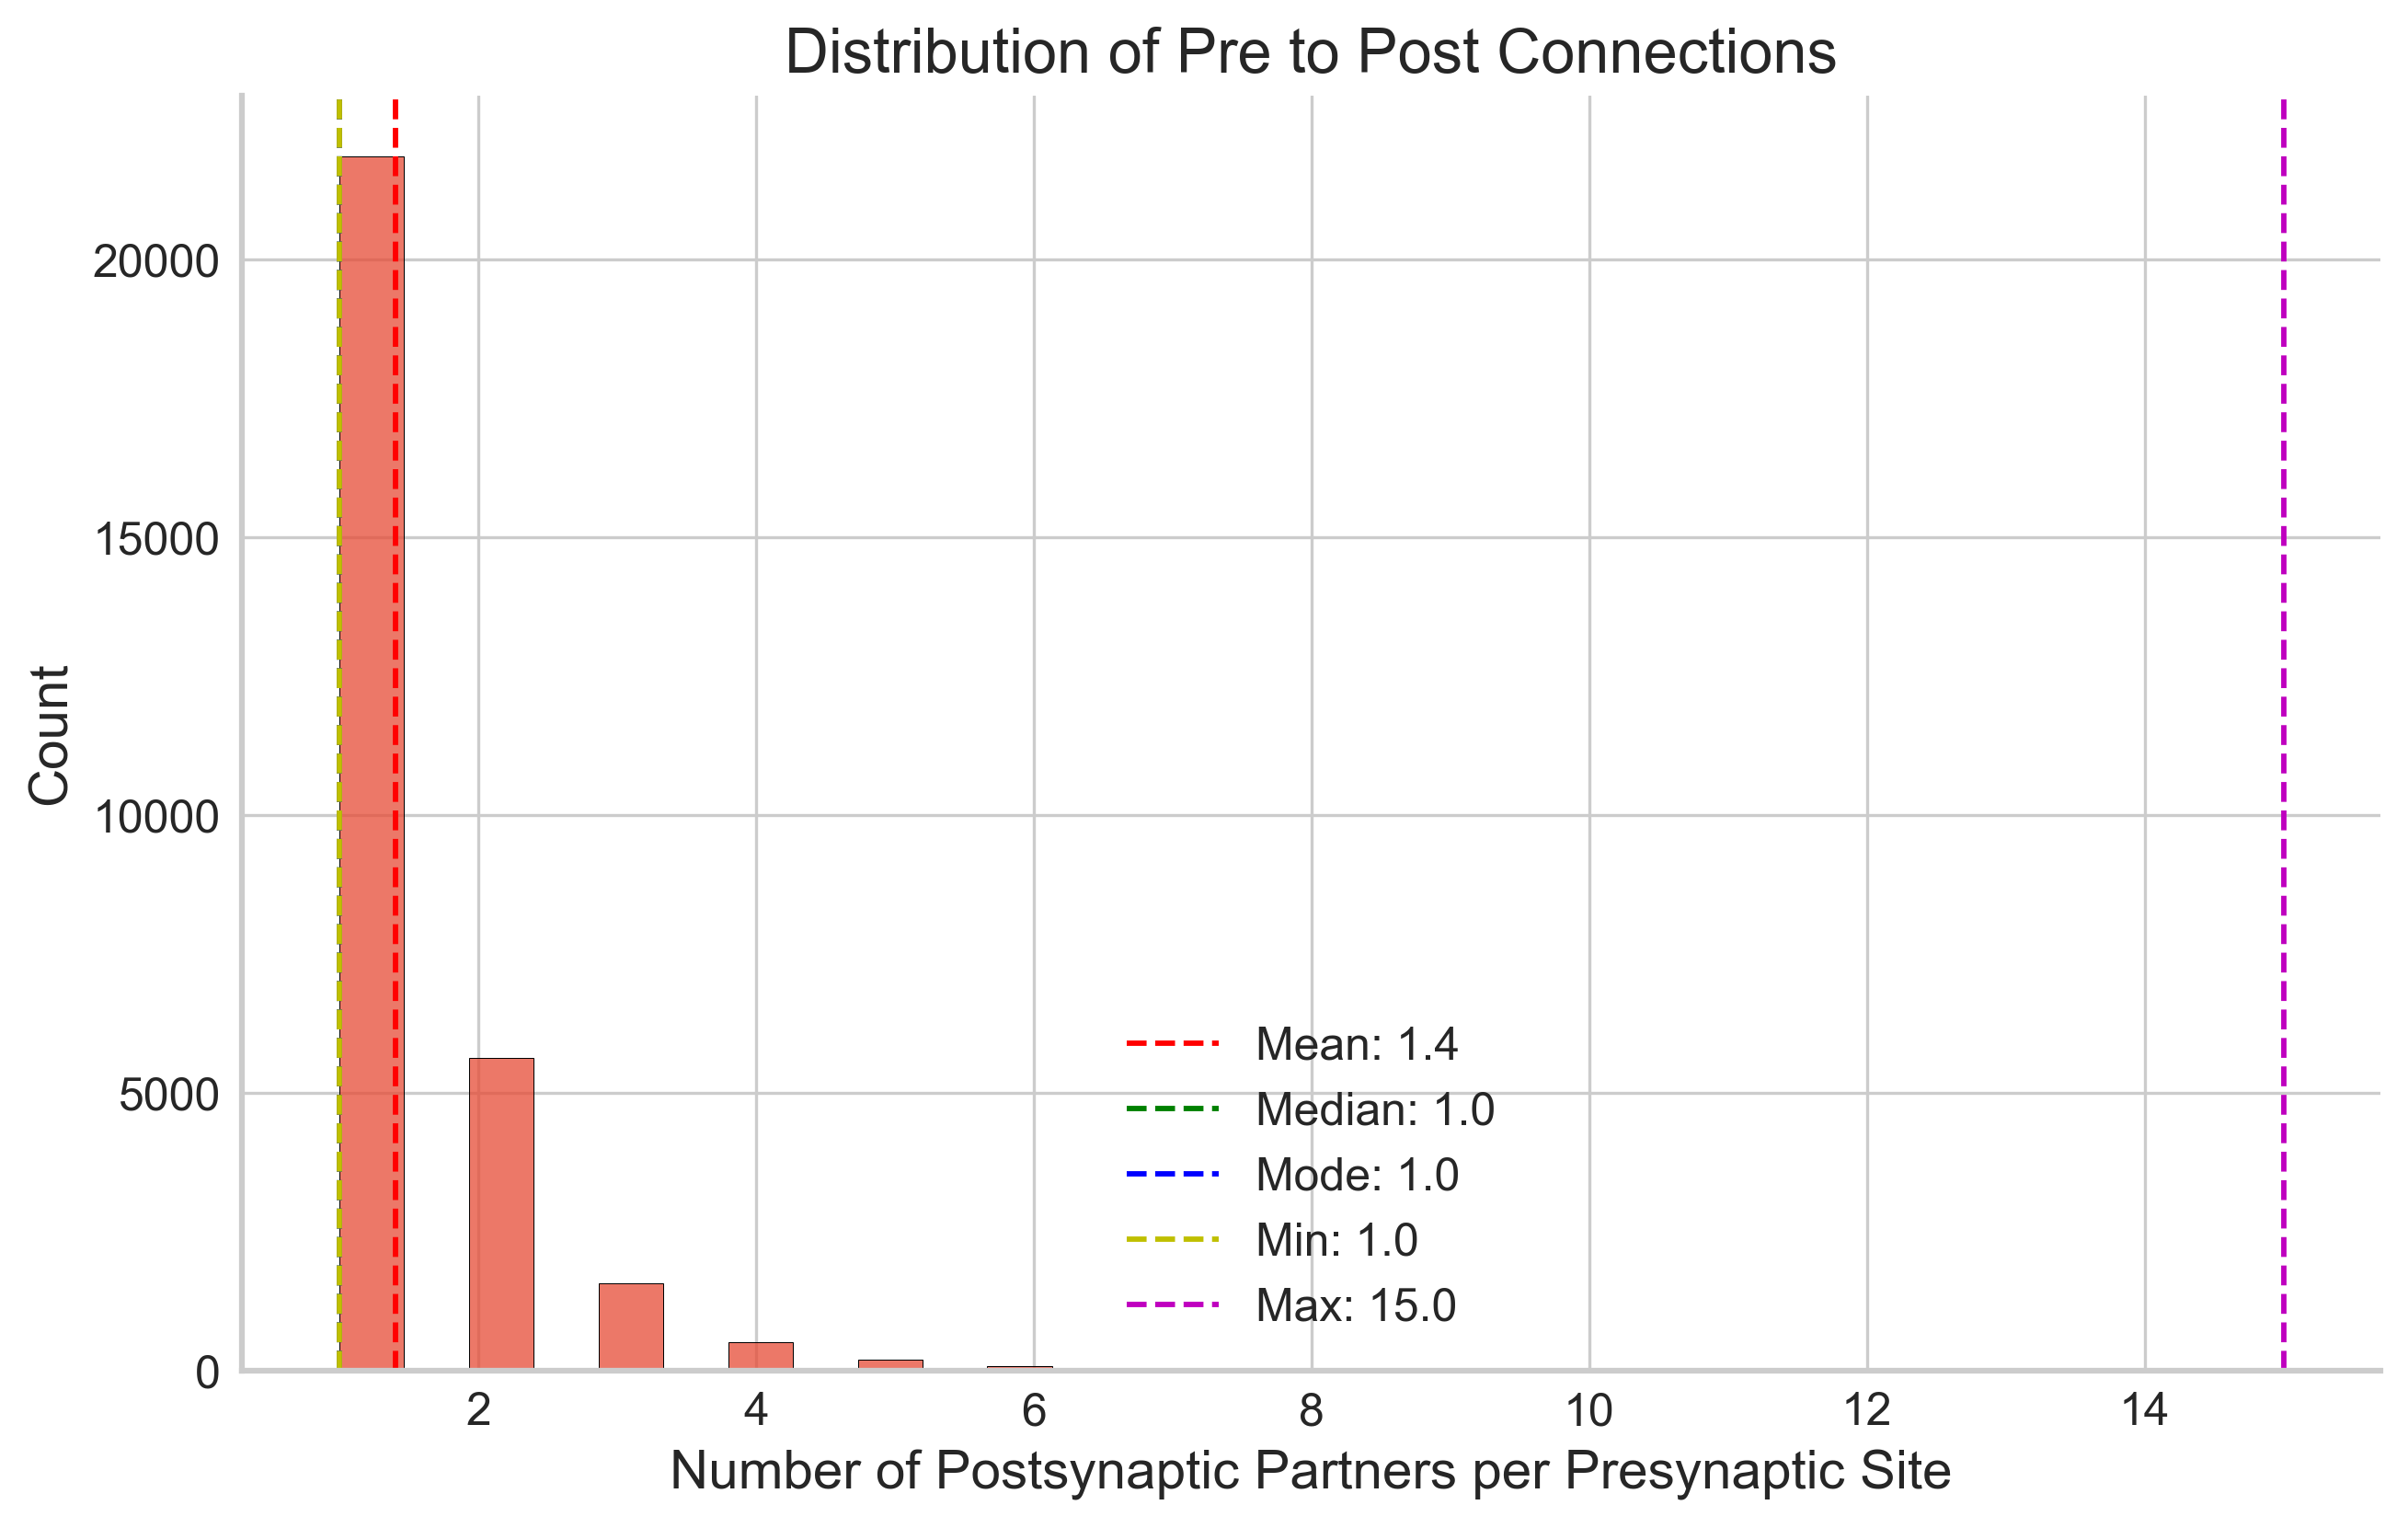


Minimum distance pairs:
         pre_x    pre_y     pre_z   post_x   post_y    post_z  pre_post_distance
3005   53192.4  81608.8   69200.0  53192.4  81608.8   69200.0                0.0
14308  44030.6  80199.0  133550.0  44030.6  80199.0  133550.0                0.0
19459  44868.5  78907.0  160300.0  44868.5  78907.0  160300.0                0.0

Maximum distance pairs:
         pre_x     pre_y    pre_z   post_x   post_y   post_z  pre_post_distance
4432  40110.14  71026.56  37250.0  38228.0  69220.8  37150.0        2610.214581


<Figure size 1920x1320 with 0 Axes>

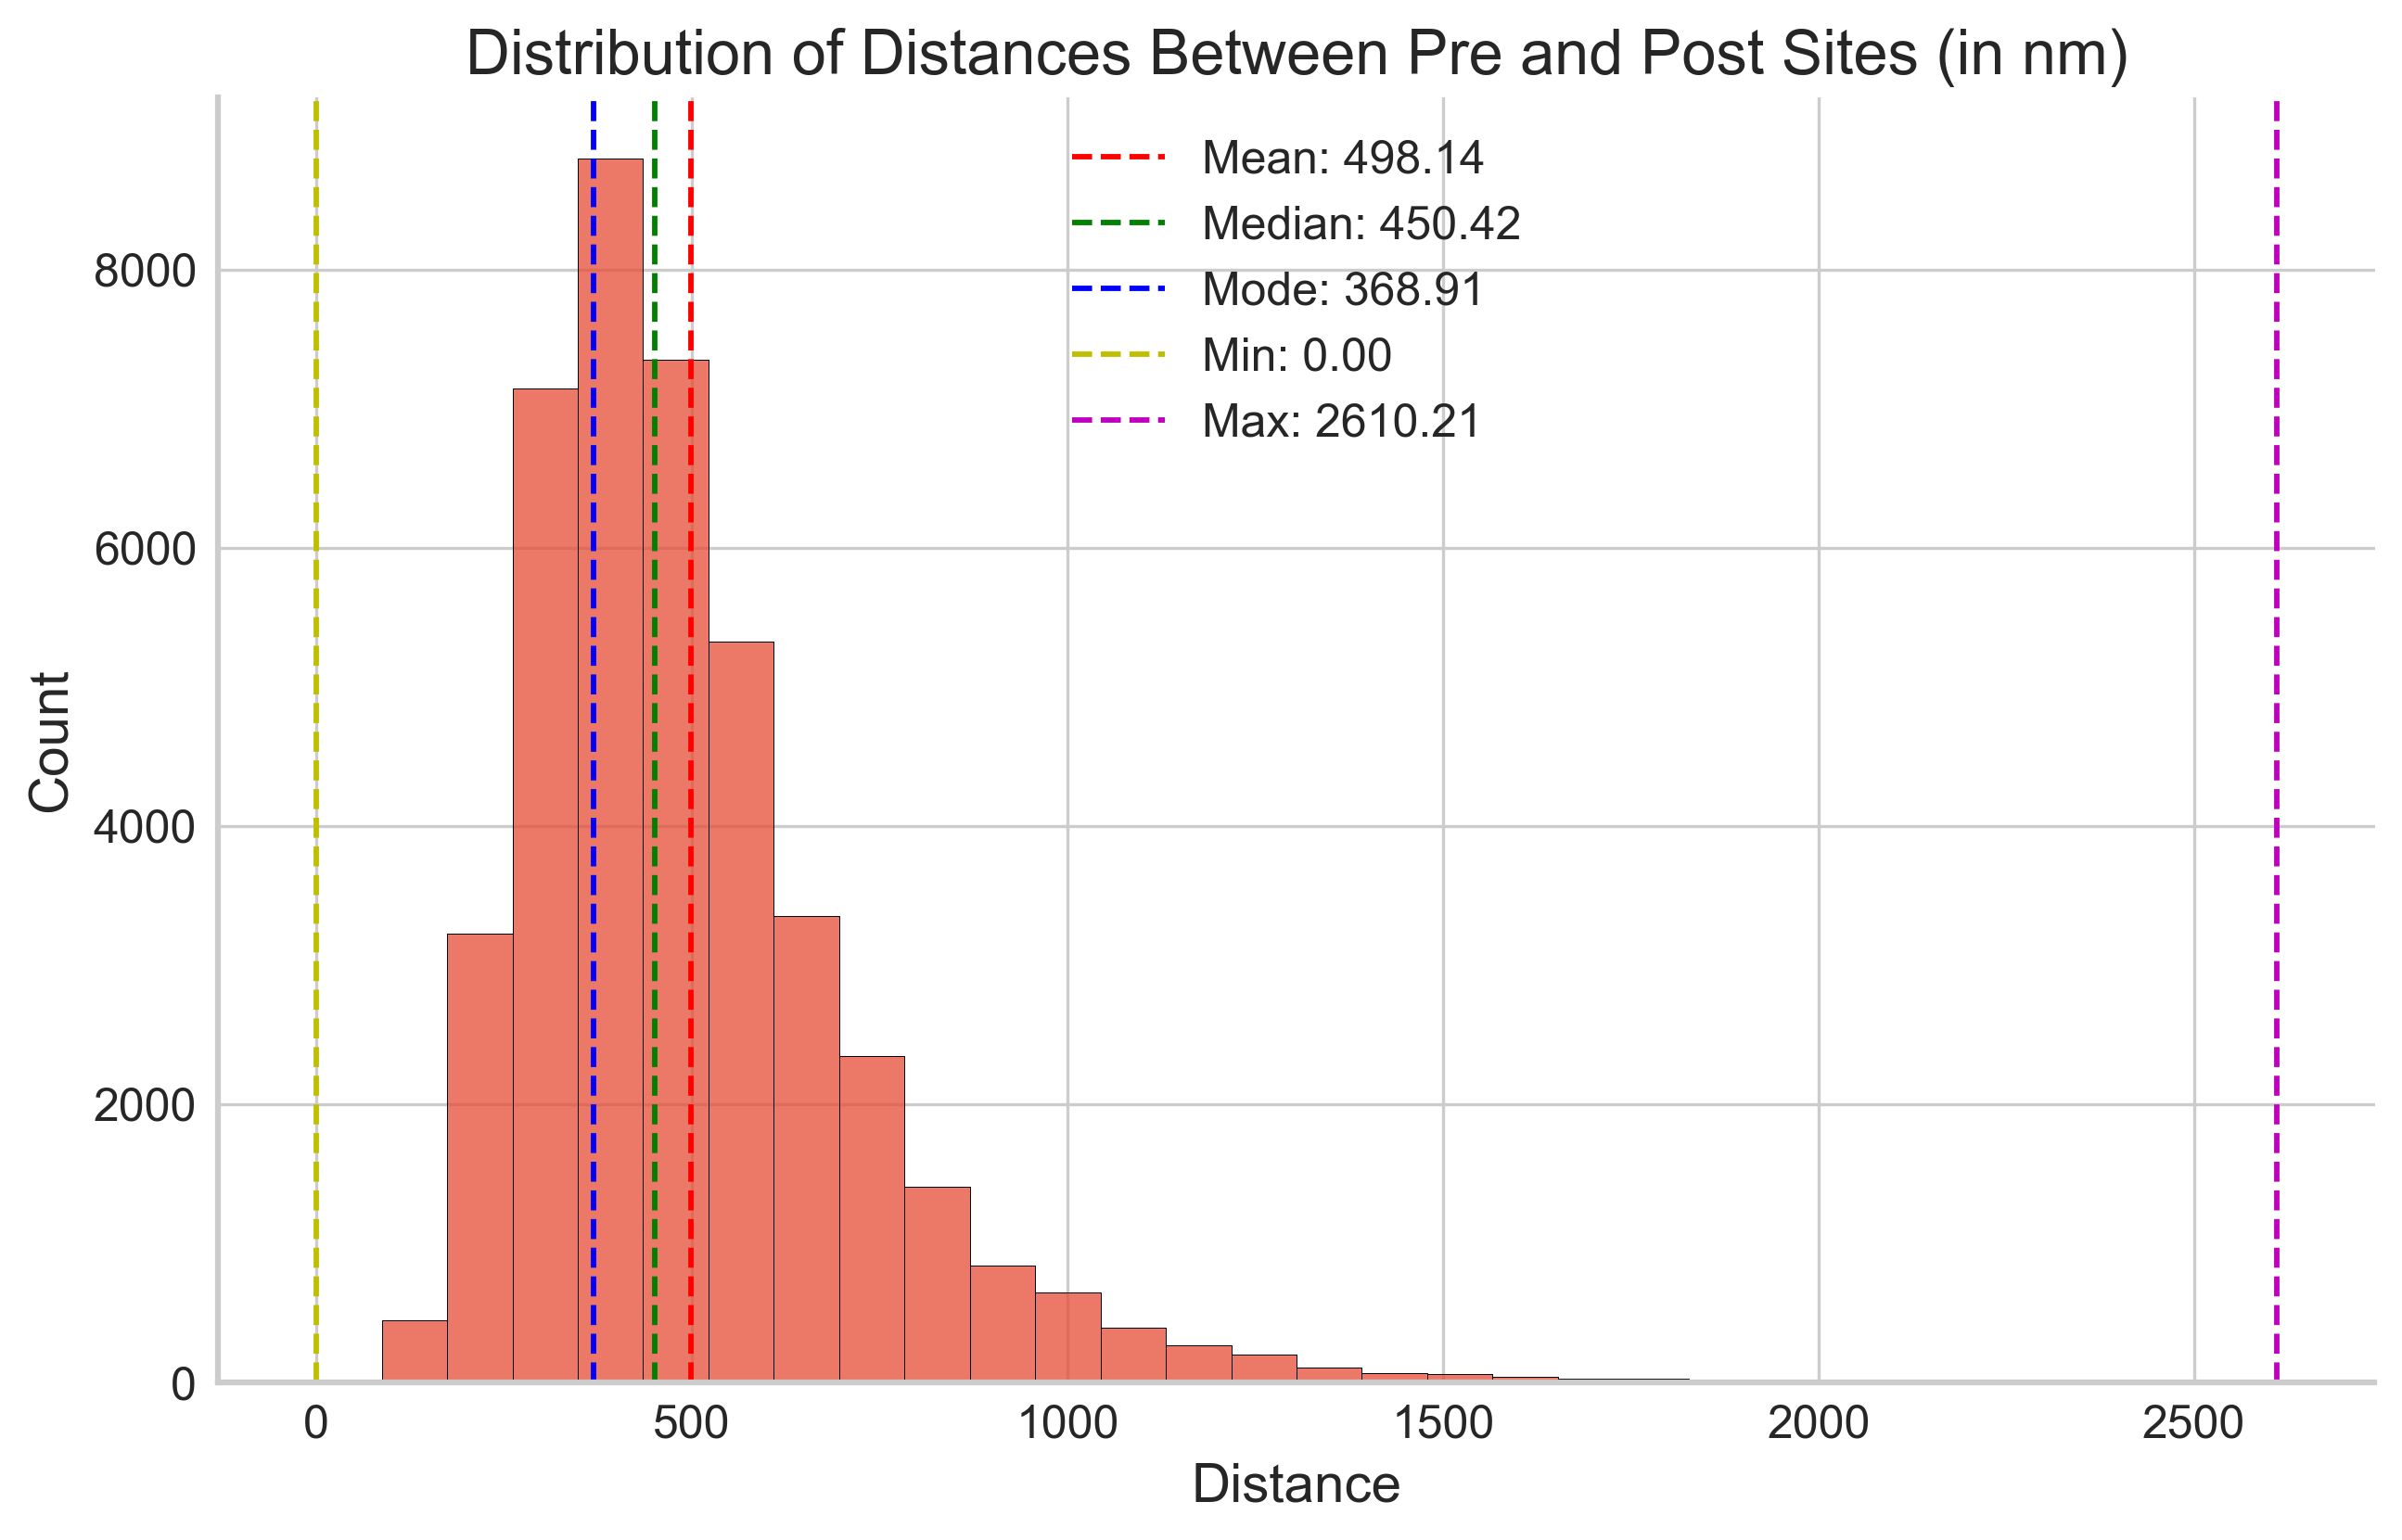

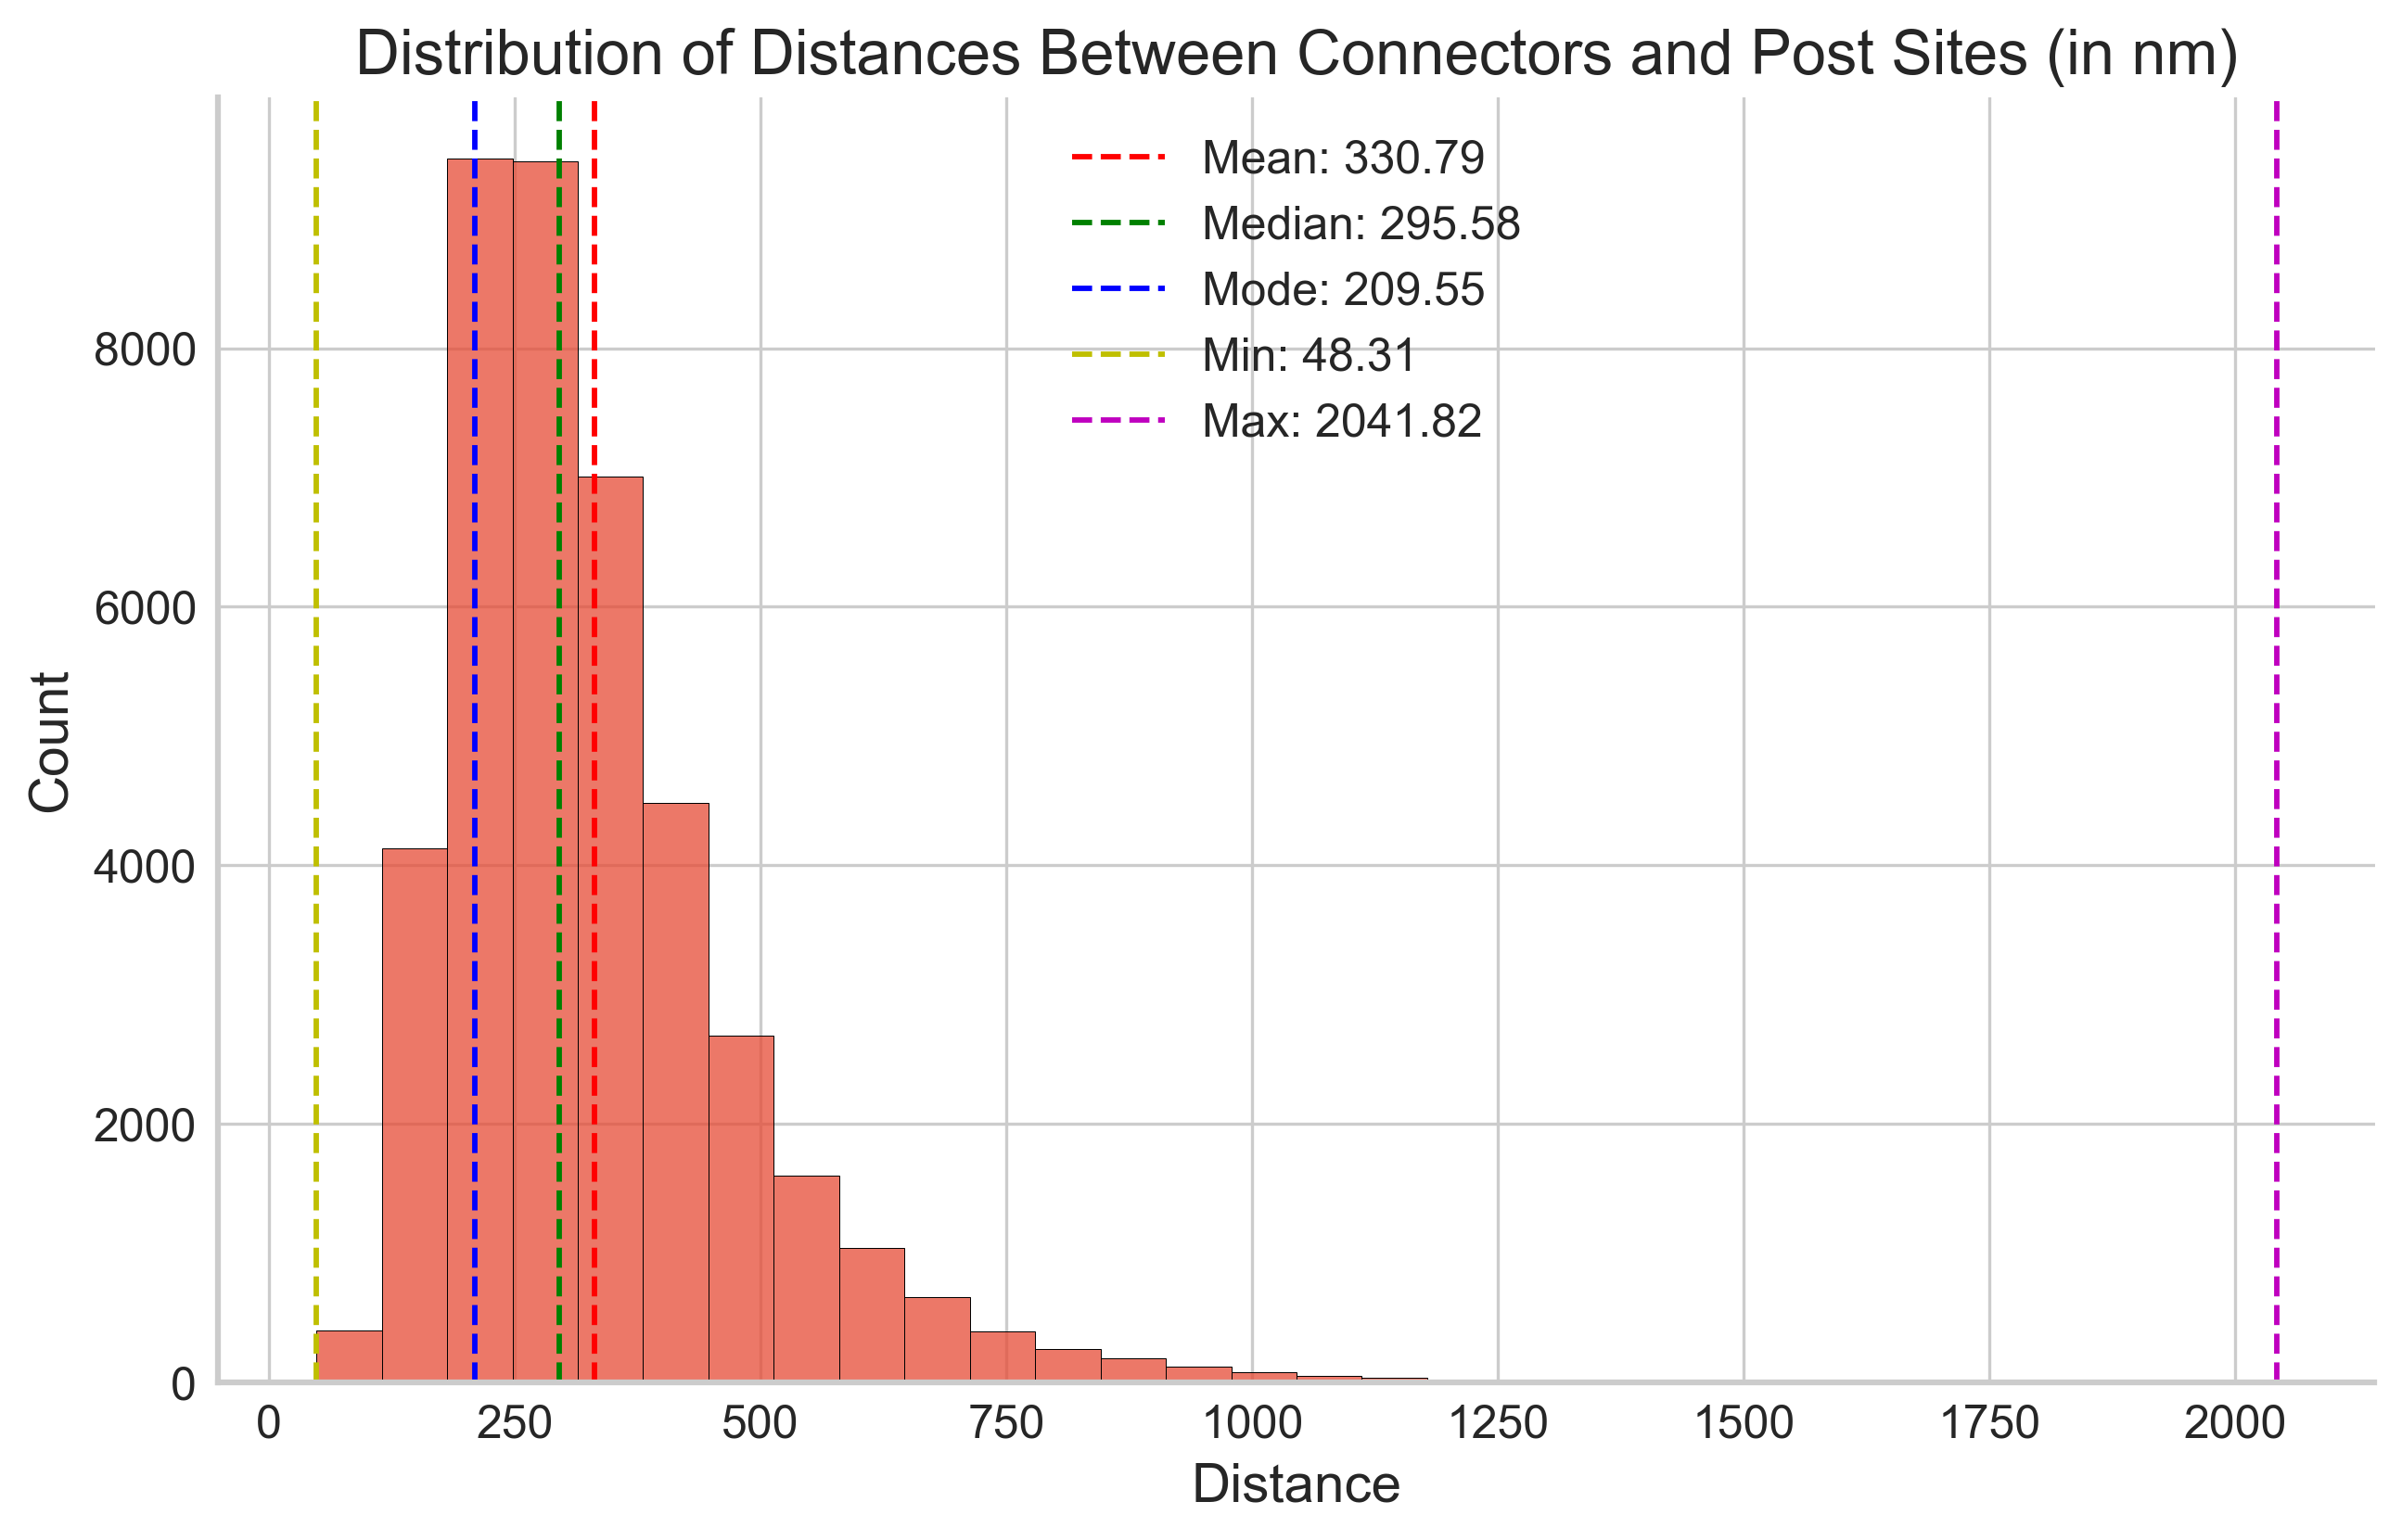

In [95]:
import seaborn as sns
from scipy.stats import mode
import matplotlib as mpl
import os

import matplotlib.pyplot as plt

# Set the style for the plots
# sns.set_theme(style="whitegrid")
# Set up publication-quality styling
plt.style.use(['seaborn-v0_8-whitegrid', 'seaborn-v0_8-paper'])
mpl.rcParams.update({
    'font.family': 'Arial',
    'font.size': 12,
    'axes.linewidth': 1.5,
    'axes.labelsize': 14,
    'axes.titlesize': 16,
    'xtick.major.width': 1.5,
    'ytick.major.width': 1.5,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'legend.frameon': False,
    'figure.dpi': 300,
    'axes.spines.top': False,
    'axes.spines.right': False
})

# Set color palette (Nature-style)
colors = ['#E64B35', '#4DBBD5', '#00A087', '#3C5488', '#F39B7F']
sns.set_palette(colors)

# 1. Distribution of pre to post connections
pre_to_post_counts = df.groupby('pre_neuron')['post_neuron'].size()
# pre_to_post_counts = df.groupby(['pre_x', 'pre_y', 'pre_z'])['post_neuron'].count()


# Calculate statistics
mean_pre_to_post = pre_to_post_counts.mean()
median_pre_to_post = pre_to_post_counts.median()
mode_pre_to_post = mode(pre_to_post_counts).mode
min_pre_to_post = pre_to_post_counts.min()
max_pre_to_post = pre_to_post_counts.max()

# 1. Distribution of pre to post connections
# pre_to_post_counts = df.groupby('pre_neuron')['post_neuron'].count()
pre_to_post_counts = df.groupby(['pre_x', 'pre_y', 'pre_z'])['post_neuron'].count()

# Calculate statistics
mean_pre_to_post = pre_to_post_counts.mean()
median_pre_to_post = pre_to_post_counts.median()
mode_pre_to_post = mode(pre_to_post_counts).mode 
min_pre_to_post = pre_to_post_counts.min()
max_pre_to_post = pre_to_post_counts.max()

print(f'Mean: {mean_pre_to_post:.1f}')
print(f'Median: {median_pre_to_post:.1f}')
print(f'Mode: {mode_pre_to_post:.1f}')
print(f'Min: {min_pre_to_post:.1f}')
print(f'Max: {max_pre_to_post:.1f}')


# Plot the distribution
plt.figure(figsize=(10, 6))
sns.histplot(pre_to_post_counts, kde=False, bins=30)
plt.axvline(mean_pre_to_post, color='r', linestyle='--', label=f'Mean: {mean_pre_to_post:.1f}')
plt.axvline(median_pre_to_post, color='g', linestyle='--', label=f'Median: {median_pre_to_post:.1f}')
plt.axvline(mode_pre_to_post, color='b', linestyle='--', label=f'Mode: {mode_pre_to_post:.1f}')
plt.axvline(min_pre_to_post, color='y', linestyle='--', label=f'Min: {min_pre_to_post:.1f}')
plt.axvline(max_pre_to_post, color='m', linestyle='--', label=f'Max: {max_pre_to_post:.1f}')
plt.title('Distribution of Pre to Post Connections')
plt.xlabel('Number of Postsynaptic Partners per Presynaptic Site')
plt.ylabel('Count')
plt.legend()
sns.despine()
plt.show()
plt.savefig(os.path.join(output_dir,'pre_post_connectivity_distributions.png'))

# 2. Distribution of distances between pre and post sites
df['pre_post_distance'] = ((df['pre_x'] - df['post_x'])**2 + (df['pre_y'] - df['post_y'])**2 + (df['pre_z'] - df['post_z'])**2)**0.5

# Find min and max distance pairs
min_dist_pairs = df[df['pre_post_distance'] == df['pre_post_distance'].min()]
max_dist_pairs = df[df['pre_post_distance'] == df['pre_post_distance'].max()]

print("\nMinimum distance pairs:")
print(min_dist_pairs[['pre_x', 'pre_y', 'pre_z', 'post_x', 'post_y', 'post_z', 'pre_post_distance']].to_string())
print("\nMaximum distance pairs:")
print(max_dist_pairs[['pre_x', 'pre_y', 'pre_z', 'post_x', 'post_y', 'post_z', 'pre_post_distance']].to_string())

# Calculate statistics
mean_pre_post_distance = df['pre_post_distance'].mean()
median_pre_post_distance = df['pre_post_distance'].median()
mode_pre_post_distance = mode(df['pre_post_distance']).mode
min_pre_post_distance = df['pre_post_distance'].min()
max_pre_post_distance = df['pre_post_distance'].max()

# Plot the distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['pre_post_distance'], kde=False, bins=30)
plt.axvline(mean_pre_post_distance, color='r', linestyle='--', label=f'Mean: {mean_pre_post_distance:.2f}')
plt.axvline(median_pre_post_distance, color='g', linestyle='--', label=f'Median: {median_pre_post_distance:.2f}')
plt.axvline(mode_pre_post_distance, color='b', linestyle='--', label=f'Mode: {mode_pre_post_distance:.2f}')
plt.axvline(min_pre_post_distance, color='y', linestyle='--', label=f'Min: {min_pre_post_distance:.2f}')
plt.axvline(max_pre_post_distance, color='m', linestyle='--', label=f'Max: {max_pre_post_distance:.2f}')
plt.title('Distribution of Distances Between Pre and Post Sites (in nm)')
plt.xlabel('Distance')
plt.ylabel('Count')
plt.legend()
sns.despine()
plt.show()
# plt.savefig(os.path.join(output_dir,'pre_post_distance_distributions.png'))


# 3. Distribution of distances between connectors and post sites
df['connector_post_distance'] = ((df['connector_x'] - df['post_x'])**2 + (df['connector_y'] - df['post_y'])**2 + (df['connector_z'] - df['post_z'])**2)**0.5

# Calculate statistics
mean_connector_post_distance = df['connector_post_distance'].mean()
median_connector_post_distance = df['connector_post_distance'].median()
mode_connector_post_distance = mode(df['connector_post_distance']).mode
min_connector_post_distance = df['connector_post_distance'].min()
max_connector_post_distance = df['connector_post_distance'].max()

# Plot the distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['connector_post_distance'], kde=False, bins=30)
plt.axvline(mean_connector_post_distance, color='r', linestyle='--', label=f'Mean: {mean_connector_post_distance:.2f}')
plt.axvline(median_connector_post_distance, color='g', linestyle='--', label=f'Median: {median_connector_post_distance:.2f}')
plt.axvline(mode_connector_post_distance, color='b', linestyle='--', label=f'Mode: {mode_connector_post_distance:.2f}')
plt.axvline(min_connector_post_distance, color='y', linestyle='--', label=f'Min: {min_connector_post_distance:.2f}')
plt.axvline(max_connector_post_distance, color='m', linestyle='--', label=f'Max: {max_connector_post_distance:.2f}')
plt.title('Distribution of Distances Between Connectors and Post Sites (in nm)')
plt.xlabel('Distance')
plt.ylabel('Count')
plt.legend()
sns.despine()
plt.show()
# plt.savefig(os.path.join(output_dir,'connector_post_distance_distributions.png'))

Mean: 1.4
Median: 1.0
Mode: 1.0
Min: 1.0
Max: 15.0


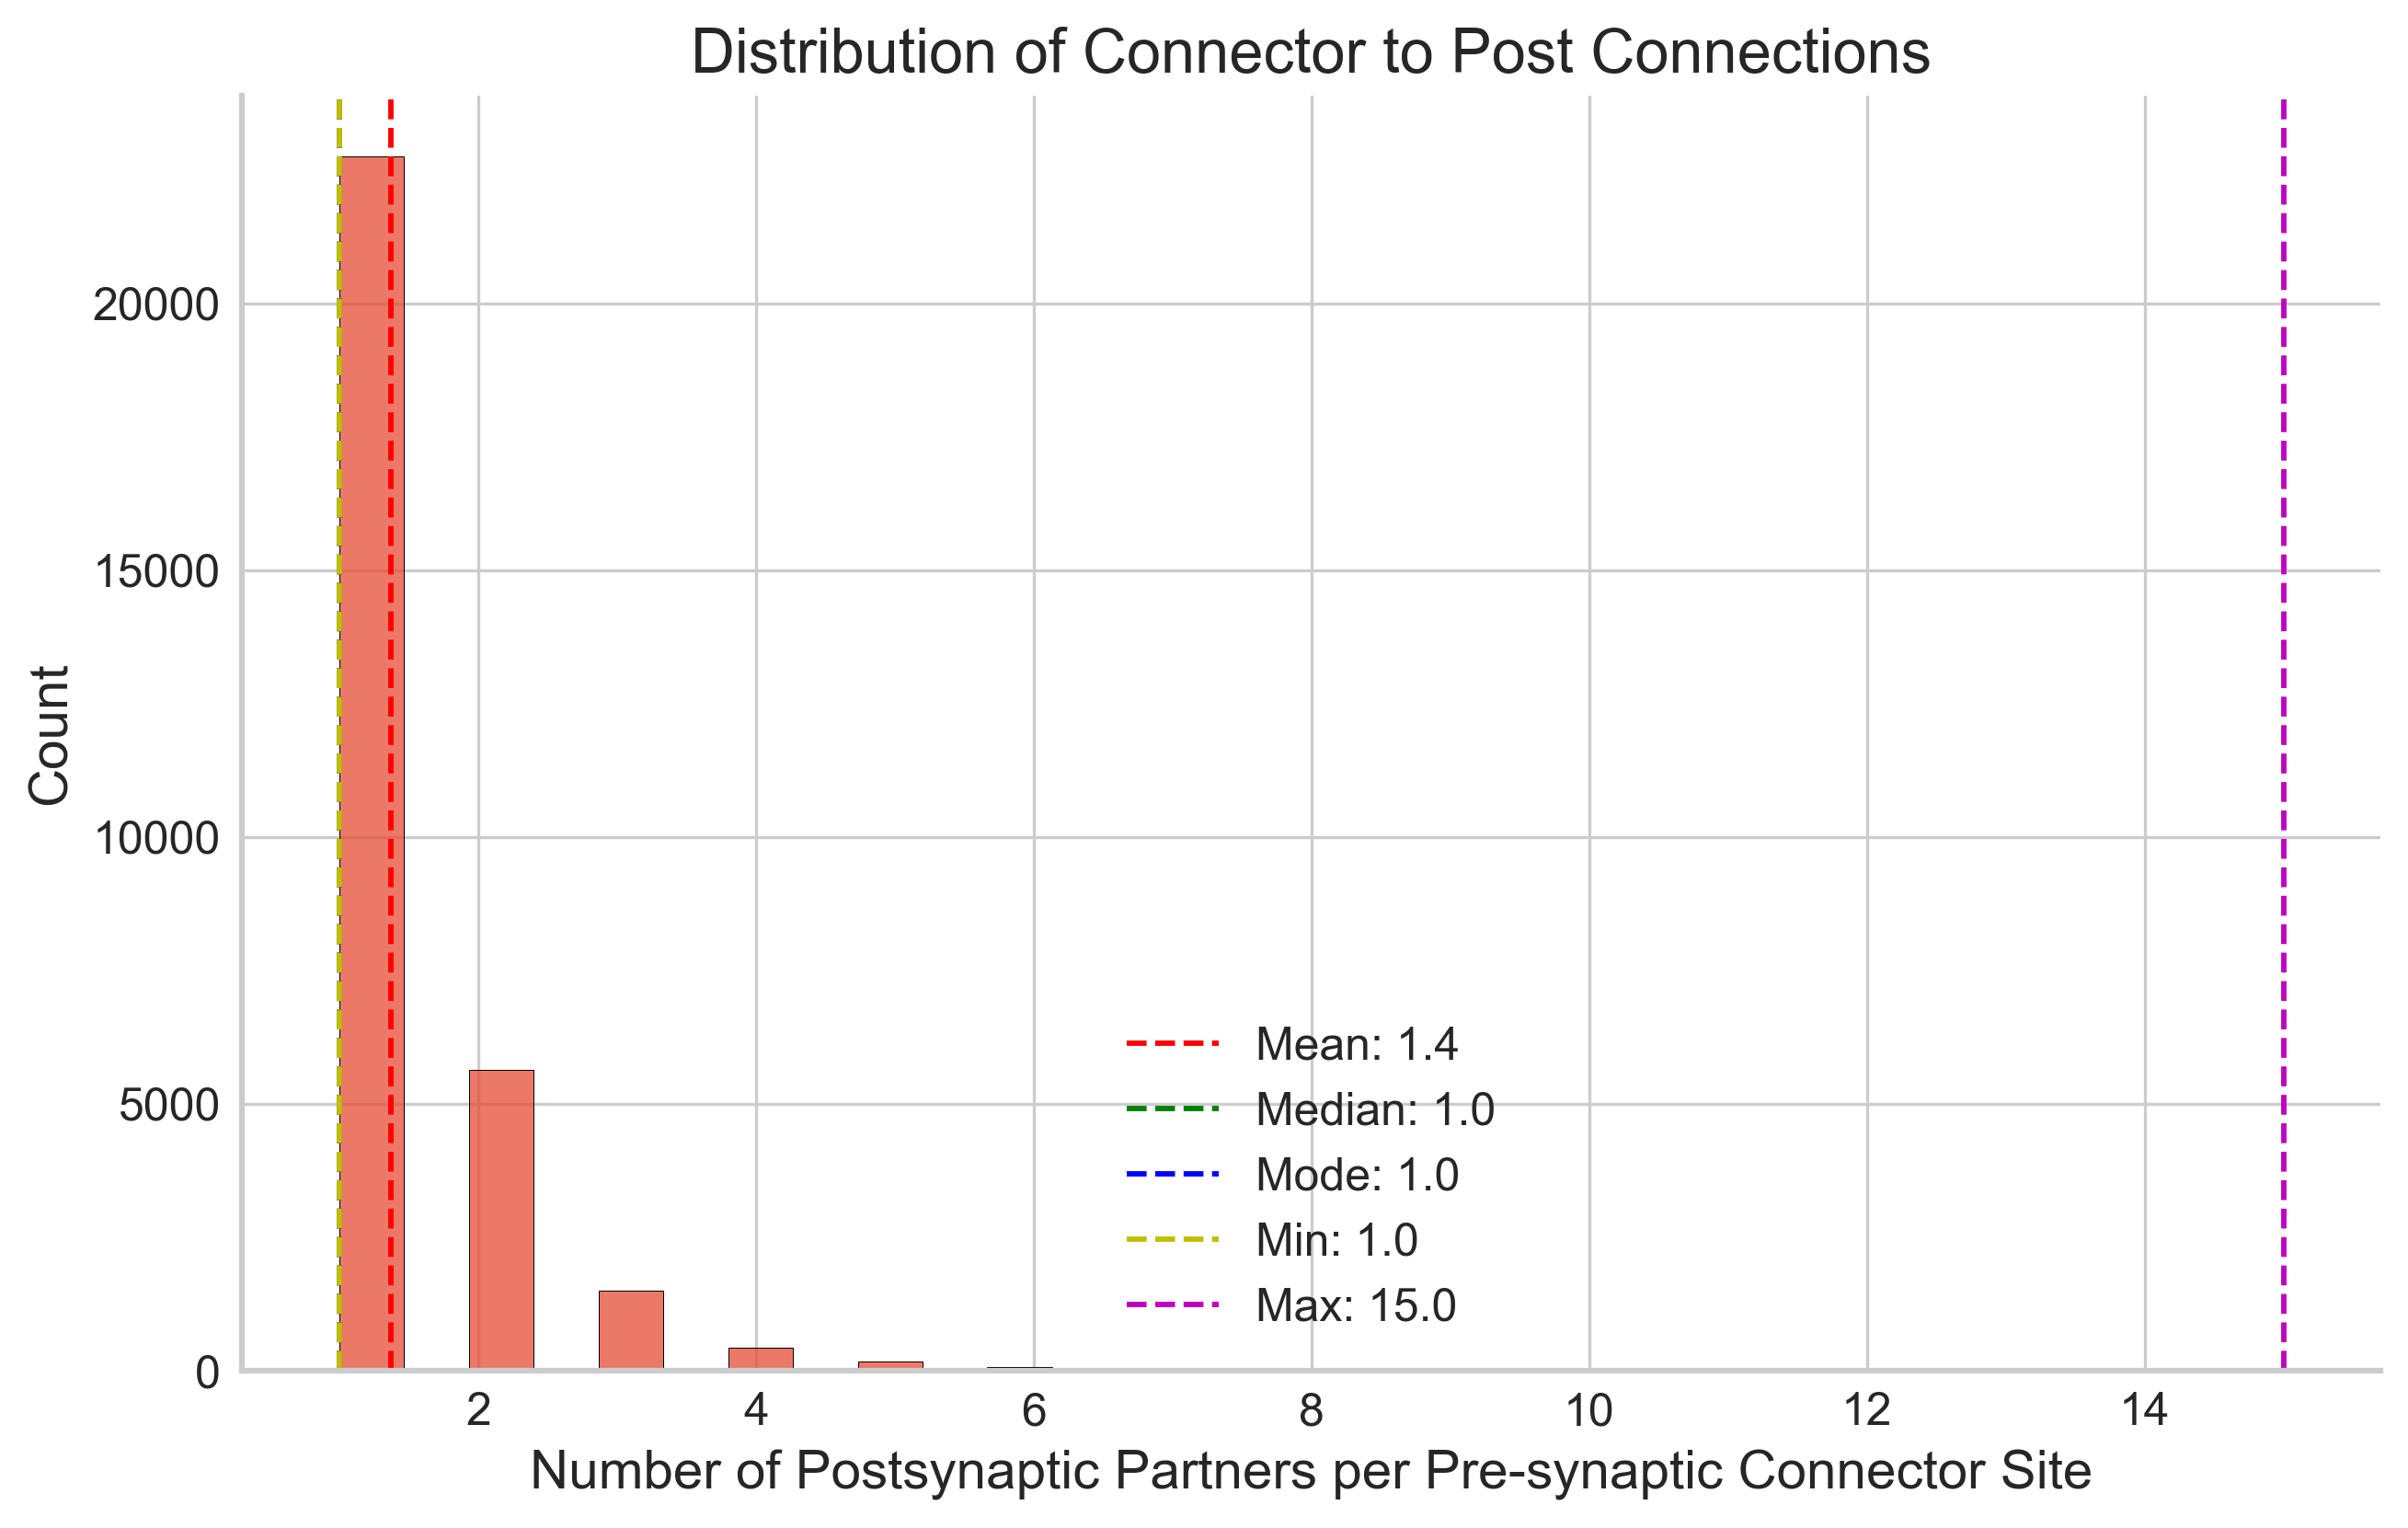


Connectors with maximum (15) post-synaptic partners:

Connector coordinates (x, y, z):
Connector at (50914.3, 74994.9, 49600.0)

Post-synaptic partners:
       pre_neuron   post_x   post_y   post_z  post_neuron  confidence1
17994    17698681  51003.6  74654.8  49850.0       216195            5
18001    17698681  50745.2  74639.6  49900.0       216181            5
18004    17698681  51079.6  74658.6  49700.0       216147            5
18007    17698681  50817.4  75293.2  49700.0       216131            5
18010    17698681  50707.2  75156.4  49700.0       216123            5
18012    17698681  50650.2  74924.6  49700.0       216115            5
18014    17698681  51129.0  74787.8  50100.0       853526            5
18021    17698681  50509.6  74727.0  49900.0      8213784            5
18026    17698681  50988.4  75304.6  49650.0     15770521            5
18027    17698681  50927.6  75122.2  49500.0     15770521            5
18030    17698681  51212.6  74746.0  49700.0     15770521        

In [94]:
results_output_dir = "/Volumes/SamiaSan/PhD_extras/figs/synapse_analysis_plots/seymour"
os.makedirs(results_output_dir, exist_ok=True)

# 1. Distribution of connectors to post connections
# pre_to_post_counts = df.groupby('connector_id')['post_neuron'].count()
pre_to_post_counts = df.groupby(['connector_x', 'connector_y', 'connector_z'])['post_neuron'].count()

# Calculate statistics
mean_pre_to_post = pre_to_post_counts.mean()
median_pre_to_post = pre_to_post_counts.median()
mode_pre_to_post = mode(pre_to_post_counts).mode 
min_pre_to_post = pre_to_post_counts.min()
max_pre_to_post = pre_to_post_counts.max()

print(f'Mean: {mean_pre_to_post:.1f}')
print(f'Median: {median_pre_to_post:.1f}')
print(f'Mode: {mode_pre_to_post:.1f}')
print(f'Min: {min_pre_to_post:.1f}')
print(f'Max: {max_pre_to_post:.1f}')


# Plot the distribution
fig = plt.figure(figsize=(10, 6))
sns.histplot(pre_to_post_counts, kde=False, bins=30)
plt.axvline(mean_pre_to_post, color='r', linestyle='--', label=f'Mean: {mean_pre_to_post:.1f}')
plt.axvline(median_pre_to_post, color='g', linestyle='--', label=f'Median: {median_pre_to_post:.1f}')
plt.axvline(mode_pre_to_post, color='b', linestyle='--', label=f'Mode: {mode_pre_to_post:.1f}')
plt.axvline(min_pre_to_post, color='y', linestyle='--', label=f'Min: {min_pre_to_post:.1f}')
plt.axvline(max_pre_to_post, color='m', linestyle='--', label=f'Max: {max_pre_to_post:.1f}')
plt.title('Distribution of Connector to Post Connections')
plt.xlabel('Number of Postsynaptic Partners per Pre-synaptic Connector Site')
plt.ylabel('Count')
plt.legend()
sns.despine()
plt.show()
fig.savefig(os.path.join(results_output_dir,'connector_post_connectivity_distributions.svg'))
fig.savefig(os.path.join(results_output_dir,'connector_post_connectivity_distributions.png'))

# Find connectors with maximum post-synaptic partners
max_post_count = pre_to_post_counts.max()
max_connectors = pre_to_post_counts[pre_to_post_counts == max_post_count]

print(f"\nConnectors with maximum ({max_post_count}) post-synaptic partners:")
print("\nConnector coordinates (x, y, z):")
for idx, count in max_connectors.items():
    print(f"Connector at ({idx[0]}, {idx[1]}, {idx[2]})")
    
    # Get all post-synaptic partners for this connector
    post_partners = df[
        (df['connector_x'] == idx[0]) & 
        (df['connector_y'] == idx[1]) & 
        (df['connector_z'] == idx[2])
    ][['pre_neuron', 'post_x', 'post_y', 'post_z', 'post_neuron', 'confidence1']]
    
    print("\nPost-synaptic partners:")
    print(post_partners.to_string())
    print("\n" + "-"*50)

In [120]:
# Check the number of unique connectors in both dataframes
num_unique_connectors_df = df.groupby(['connector_id']).size().shape[0]
num_unique_connectors_seymour = connectors_df.groupby(['connector_id']).size().shape[0]

print(f"Number of unique connectors in df: {num_unique_connectors_df}")
print(f"Number of unique connectors in seymour_df: {num_unique_connectors_seymour}")

# Let's check if there are any connectors in one df that aren't in the other
df_connector_set = set(zip(df['connector_x'], df['connector_y'], df['connector_z']))
seymour_connector_set = set(zip(connectors_df['x'], connectors_df['y'], connectors_df['z']))

connectors_only_in_df = df_connector_set - seymour_connector_set
connectors_only_in_seymour = seymour_connector_set - df_connector_set

print(f"\nConnectors only in df: {len(connectors_only_in_df)}")
print(f"Connectors only in seymour_df: {len(connectors_only_in_seymour)}")

# Let's look at the distribution of post-synaptic partners in both dataframes
# df_counts = df.groupby(['connector_x', 'connector_y', 'connector_z'])['post_neuron'].count()
df_counts = df.groupby(['connector_id'])['post_neuron'].count()

# seymour_counts = connectors_df.groupby(['x', 'y', 'z'])['postsynaptic_neuron'].count()
seymour_counts = connectors_df.groupby(['connector_id'])['postsynaptic_neuron'].count()


print("\ndf post-synaptic partner statistics:")
print(f"Max partners: {df_counts.max()}")
print(f"Mean partners: {df_counts.mean():.2f}")

print("\nseymour_df post-synaptic partner statistics:")
print(f"Max partners: {seymour_counts.max()}")
print(f"Mean partners: {seymour_counts.mean():.2f}")

# If there are discrepancies, let's look at some examples of high-count connectors
print("\nTop 5 connector counts in df:")
print(df_counts.sort_values(ascending=False).head())

print("\nTop 5 connector counts in seymour_df:")
print(seymour_counts.sort_values(ascending=False).head())


# Still mismatching connectors, let's look at some examples
# First, let's check if we're using the right identifiers
print("Columns in df:", df.columns)
print("\nColumns in connectors_df:", connectors_df.columns)

# Let's compare using connector_id instead of coordinates
df_counts_by_id = df.groupby('connector_id')['post_neuron'].count()
seymour_counts_by_id = connectors_df.groupby('connector_id')['postsynaptic_neuron'].count()

# Let's look at the specific connector with max partners in seymour_df
max_connector_id = seymour_counts_by_id.idxmax()
print(f"\nDetails for connector {max_connector_id} with most partners:")
print("\nIn seymour_df:")
print(connectors_df[connectors_df['connector_id'] == max_connector_id][['connector_id', 'x', 'y', 'z', 'postsynaptic_neuron']])
print("\nIn df:")
print(df[df['connector_id'] == max_connector_id][['connector_id', 'connector_x', 'connector_y', 'connector_z', 'post_neuron']])

# Check if there are any duplicate entries that might affect the counts
print("\nChecking for duplicates in df:")
duplicates = df.groupby(['connector_id','connector_x', 'connector_y', 'connector_z', 'post_neuron']).size().reset_index(name='count')
print("Entries appearing more than once:")
print(duplicates[duplicates['count'] > 1])


# Get the duplicate entries with all their columns
duplicate_ids = duplicates[duplicates['count'] > 1]['connector_id'].unique()
print("Full details of duplicate entries:")
for conn_id in duplicate_ids:
    print(f"\nConnector ID: {conn_id}")
    print("\nIn df:")
    print(df[df['connector_id'] == conn_id].sort_values(['connector_x', 'connector_y', 'connector_z', 'post_neuron']))
    print("\nIn original seymour_df:")
    print(connectors_df[connectors_df['connector_id'] == conn_id].sort_values(['x', 'y', 'z', 'postsynaptic_neuron']))
    print("\n" + "="*80)

# Check if there are any differences in confidence scores or other attributes
print("\nUnique values for duplicate entries:")
for conn_id in duplicate_ids:
    dup_entries = df[df['connector_id'] == conn_id]
    print(f"\nConnector ID: {conn_id}")
    for col in df.columns:
        unique_vals = dup_entries[col].unique()
        if len(unique_vals) > 1:
            print(f"{col}: {unique_vals}")

Number of unique connectors in df: 30641
Number of unique connectors in seymour_df: 220868

Connectors only in df: 9404
Connectors only in seymour_df: 199630

df post-synaptic partner statistics:
Max partners: 15
Mean partners: 1.37

seymour_df post-synaptic partner statistics:
Max partners: 30
Mean partners: 3.93

Top 5 connector counts in df:
connector_id
216105    15
357044    14
403210    14
248821    14
395608    12
Name: post_neuron, dtype: int64

Top 5 connector counts in seymour_df:
connector_id
3819753     30
19057367    27
22941820    26
6928632     25
10119902    24
Name: postsynaptic_neuron, dtype: int64
Columns in df: Index(['Unnamed: 0', 'connector_id', 'prenode_id', 'pre_neuron', 'confidence1',
       'postnode_id', 'post_neuron', 'confidence2', 'connector_x',
       'connector_y', 'connector_z', 'pre_x', 'pre_y', 'pre_z', 'post_x',
       'post_y', 'post_z'],
      dtype='object')

Columns in connectors_df: Index(['connector_id', 'presynaptic_neuron', 'presynaptic_neuro

KeyboardInterrupt: 

In [125]:
# Find connectors with 25 post-synaptic partners in connectors_df
connector_group = connectors_df.groupby('connector_id').agg(
    num_pres=('presynaptic_neuron', 'nunique'),
    num_posts=('postsynaptic_neuron', 'nunique')
).reset_index()

max_connectors = connector_group[connector_group['num_posts'] == 25]
print("Connectors with 25 post-synaptic partners:")
print(max_connectors)


# seymour_df  = df
# connectors_df = connectors_df

print(df[~df["connector_id"].isin(connectors_df["connector_id"].unique())].shape[0])



# For each of these connectors, let's compare their representation in both dataframes
for conn_id in max_connectors['connector_id']:
    print(f"\nAnalyzing connector_id: {conn_id}")
    
    # From connectors_df
    seymour_data = connectors_df[connectors_df['connector_id'] == conn_id]
    print("\nIn connectors_df:")
    print(f"Location: ({seymour_data['x'].iloc[0]}, {seymour_data['y'].iloc[0]}, {seymour_data['z'].iloc[0]})")
    print(f"Number of posts: {len(seymour_data['postsynaptic_neuron'].unique())}")


    
    # From df
    our_data = df[df['connector_id'] == conn_id]
    print(f"\nIn our df: {our_data.shape[0]}")
    print(f"Location: ({our_data['connector_x'].iloc[0]}, {our_data['connector_y'].iloc[0]}, {our_data['connector_z'].iloc[0]})")
    print(f"Number of posts: {len(our_data['post_neuron'].unique())}")
    
    # Check if coordinates match
    coords_match = (seymour_data['x'].iloc[0] == our_data['connector_x'].iloc[0] and
                   seymour_data['y'].iloc[0] == our_data['connector_y'].iloc[0] and
                   seymour_data['z'].iloc[0] == our_data['connector_z'].iloc[0])
    print(f"\nCoordinates match: {coords_match}")
    
    # Show missing post-synaptic partners
    seymour_posts = set(seymour_data['postsynaptic_neuron'].unique())
    our_posts = set(our_data['post_neuron'].unique())
    missing_posts = seymour_posts - our_posts
    
    print(f"\nMissing post-synaptic partners in our df: {len(missing_posts)}")
    if missing_posts:
        print("Missing partners:", missing_posts)

Connectors with 25 post-synaptic partners:
        connector_id  num_pres  num_posts
118335      19057367         1         25
12278

Analyzing connector_id: 19057367

In connectors_df:
Location: (14871.3, 41283.2, 50200.0)
Number of posts: 25

In our df: 0


IndexError: single positional indexer is out-of-bounds

In [9]:
# evaluate the min and max distance abnormailities
min_dist_pairs = df[df['connector_post_distance'] == df['connector_post_distance'].min()]
max_dist_pairs = df[df['connector_post_distance'] == df['connector_post_distance'].max()]

print("\nMinimum distance pairs:")
print(min_dist_pairs[['connector_x', 'connector_y', 'connector_z', 'post_x', 'post_y', 'post_z', 'connector_post_distance', 'confidence1', 'confidence2']].to_string())
print("\nMaximum distance pairs:")
print(max_dist_pairs[['connector_x', 'connector_y', 'connector_z', 'post_x', 'post_y', 'post_z', 'connector_post_distance', 'confidence1', 'confidence2']].to_string())


Minimum distance pairs:
         connector_x  connector_y  connector_z   post_x   post_y   post_z  connector_post_distance  confidence1  confidence2
1767533      63555.0      29448.1      42950.0  63526.5  29431.0  42950.0                33.236426            5            5
2080073      63555.0      29448.1      42950.0  63526.5  29431.0  42950.0                33.236426            5            5
3049391      63555.0      29448.1      42950.0  63526.5  29431.0  42950.0                33.236426            5            5
3419124      63555.0      29448.1      42950.0  63526.5  29431.0  42950.0                33.236426            5            5
3626939      63555.0      29448.1      42950.0  63526.5  29431.0  42950.0                33.236426            5            5
4574417      63555.0      29448.1      42950.0  63526.5  29431.0  42950.0                33.236426            5            5
5365689      63555.0      29448.1      42950.0  63526.5  29431.0  42950.0                33.236426  

1 4 9.497803632909889e-05
2 3 7.123352724682418e-05
3 42108 0.9998337884364241


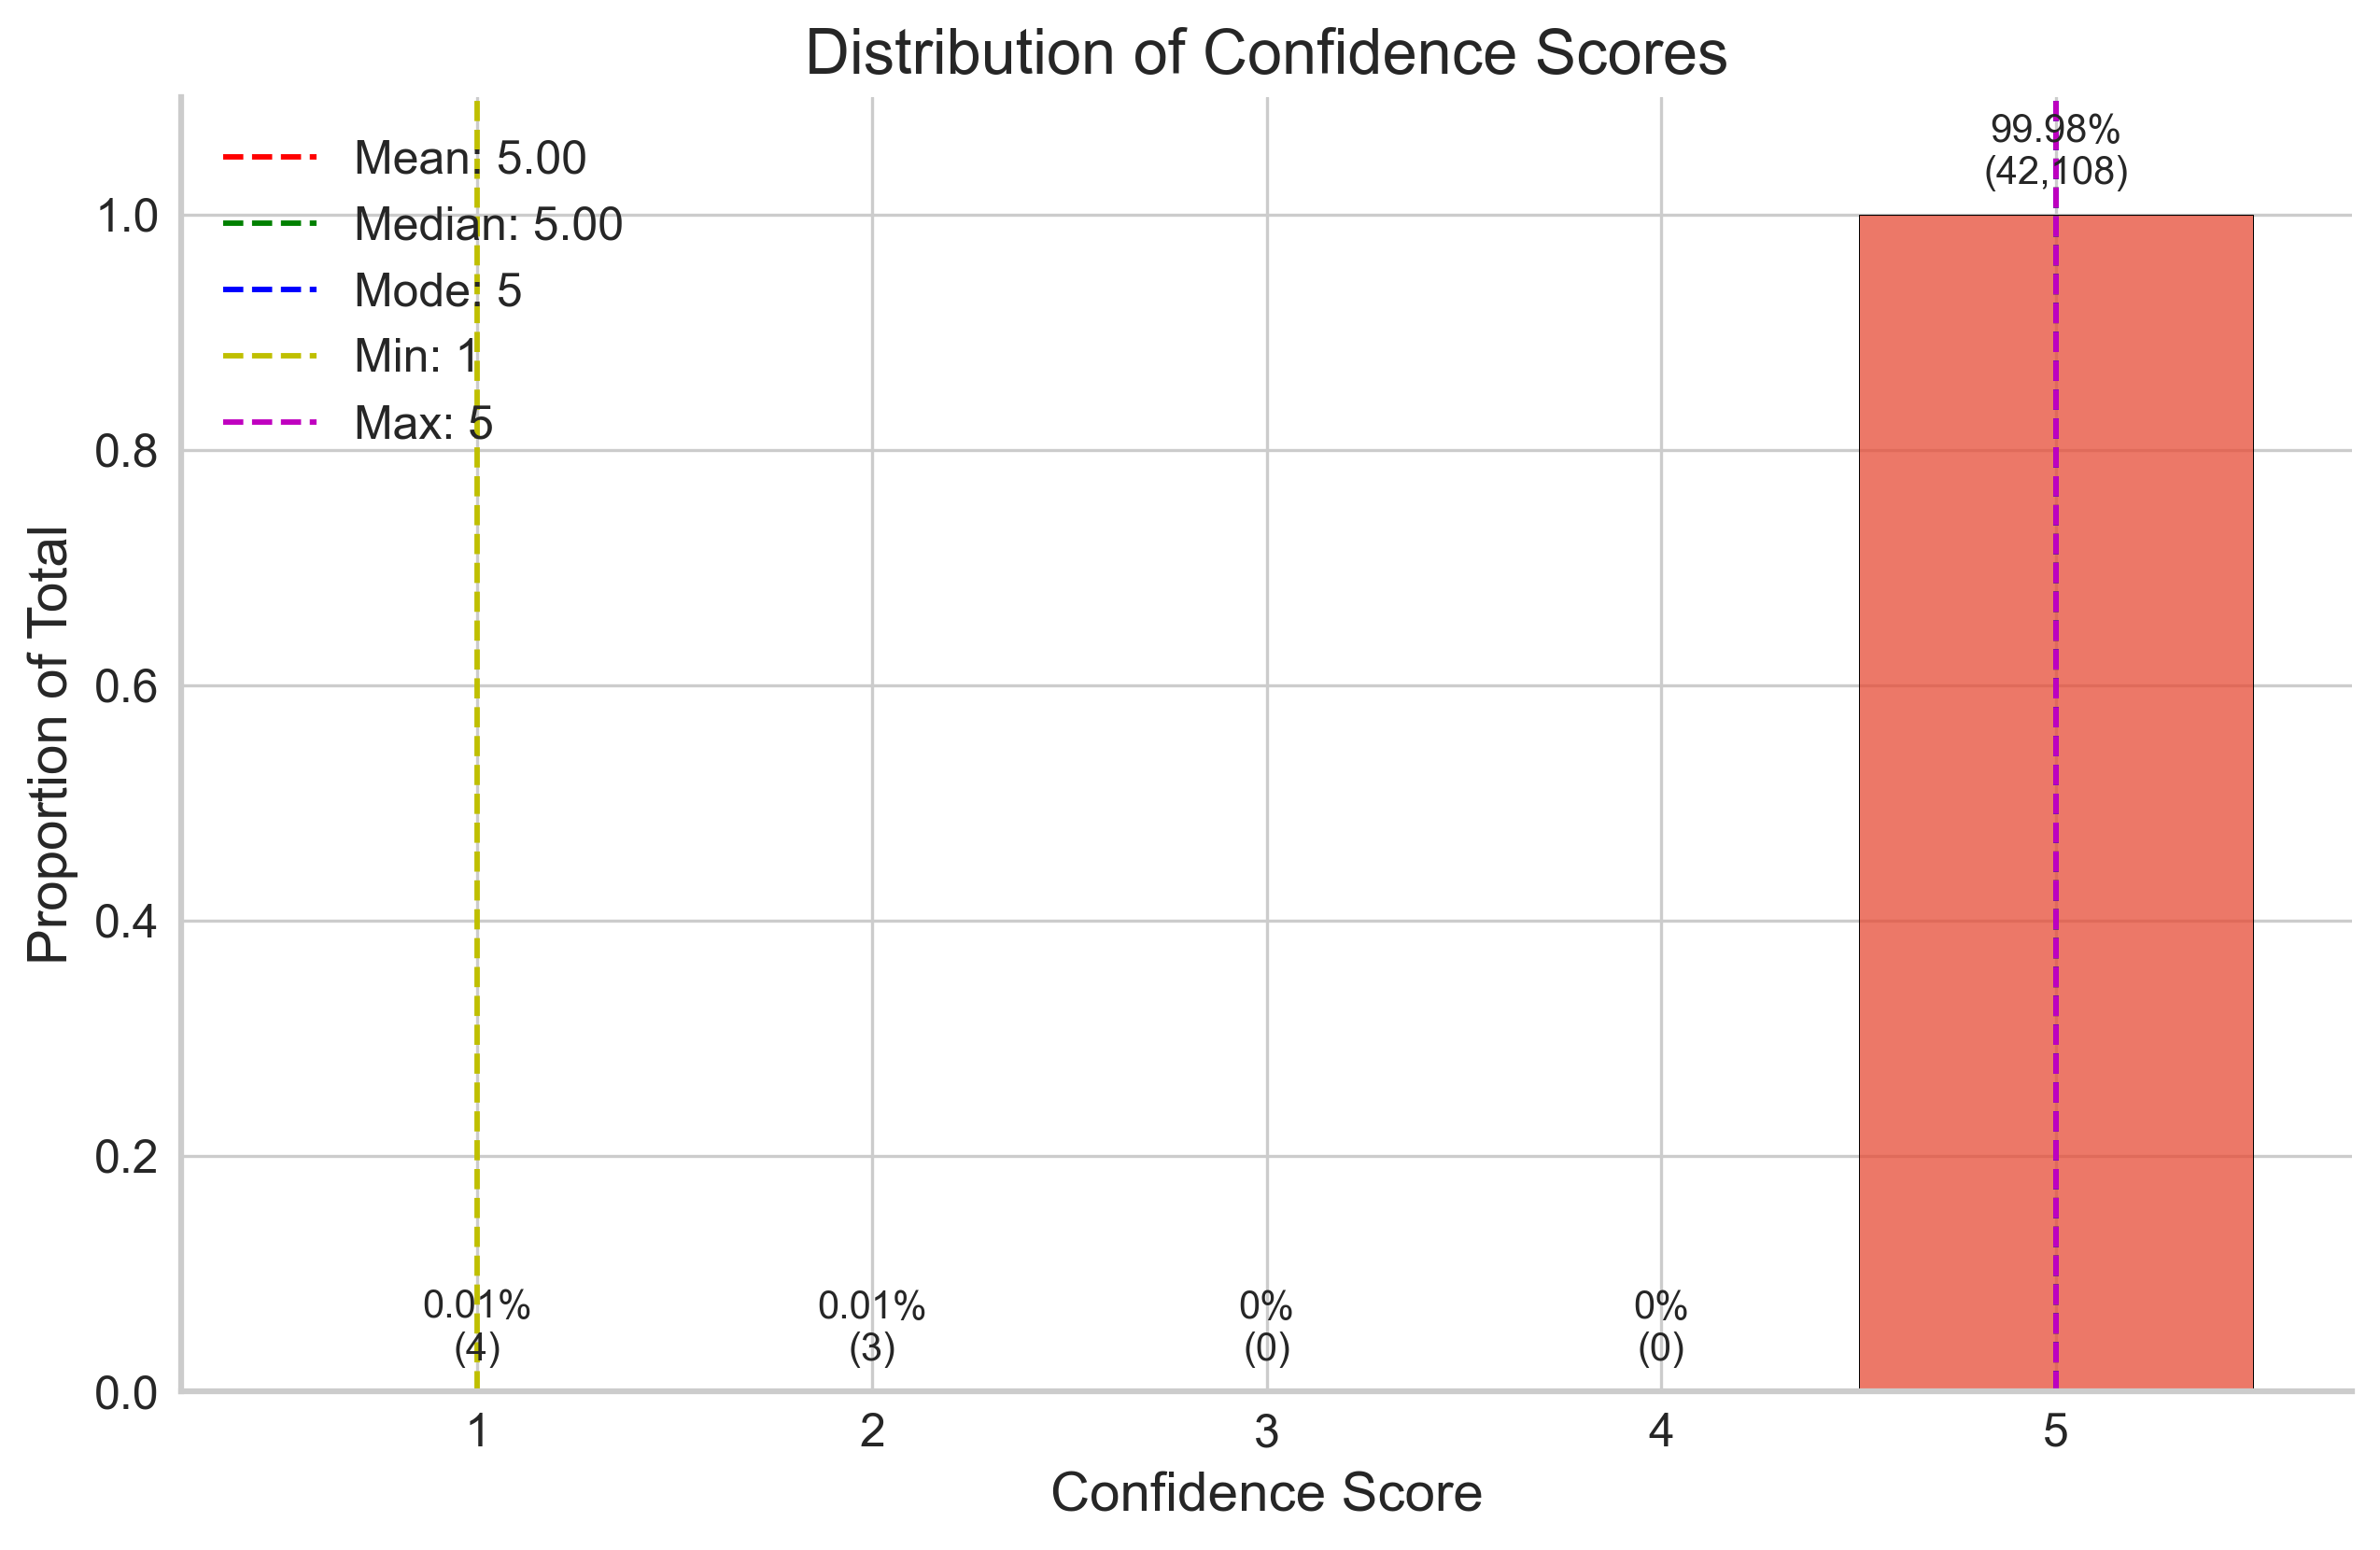


Confidence score statistics:
Score 1: 4 (0.0%)
Score 4: 3 (0.0%)
Score 5: 42,108 (100.0%)


In [113]:
import os

results_output_dir = "/Volumes/SamiaSan/PhD_extras/figs/synapse_analysis_plots/seymour"
os.makedirs(results_output_dir, exist_ok=True)

# Calculate statistics and counts
value_counts = df['confidence1'].value_counts().sort_index()
total_counts = len(df)
normalized_counts = value_counts / total_counts
mean_confidence = df['confidence1'].mean()
median_confidence = df['confidence1'].median()
mode_confidence = mode(df['confidence1']).mode
min_confidence = df['confidence1'].min()
max_confidence = df['confidence1'].max()

# Plot the distribution
fig = plt.figure(figsize=(10, 6))
ax = sns.histplot(data=df, x='confidence1', bins=5, discrete=True, stat='proportion')

# Add both normalized value and actual count on top of each bar
for i, (count, norm) in enumerate(zip(value_counts, normalized_counts), 1):
    print(i, count, norm)
    if count > 0:
        # Position text slightly above the bar
        if i == 3:
            ax.text(5, norm + 0.02, f'{norm:.2%}\n({count:,})', 
                ha='center', va='bottom', fontsize=10)
        else:
            ax.text(i, norm + 0.02, f'{norm:.2%}\n({count:,})', 
                    ha='center', va='bottom', fontsize=10)

# For zero counts, place them just above the x-axis, we know it from above
ax.text(3, 0.02, f'0%\n(0)', ha='center', va='bottom', fontsize=10)
ax.text(4, 0.02, f'0%\n(0)', ha='center', va='bottom', fontsize=10)

# Set y-axis limit to accommodate the text
plt.ylim(0, max(normalized_counts) + 0.1)  # Add 10% padding for text

plt.axvline(mean_confidence, color='r', linestyle='--', label=f'Mean: {mean_confidence:.2f}')
plt.axvline(median_confidence, color='g', linestyle='--', label=f'Median: {median_confidence:.2f}')
plt.axvline(mode_confidence, color='b', linestyle='--', label=f'Mode: {mode_confidence}')
plt.axvline(min_confidence, color='y', linestyle='--', label=f'Min: {min_confidence}')
plt.axvline(max_confidence, color='m', linestyle='--', label=f'Max: {max_confidence}')

plt.title('Distribution of Confidence Scores')
plt.xlabel('Confidence Score')
plt.ylabel('Proportion of Total')
plt.xticks([1, 2, 3, 4, 5])
plt.legend(loc='upper left')
sns.despine()
plt.show()
fig.savefig(os.path.join(output_dir,'confidence_distributions.svg'))

# Print the counts and proportions for each confidence score
print("\nConfidence score statistics:")
for score in sorted(value_counts.index):
    count = value_counts[score]
    proportion = normalized_counts[score]
    print(f"Score {score}: {count:,} ({proportion:.1%})")

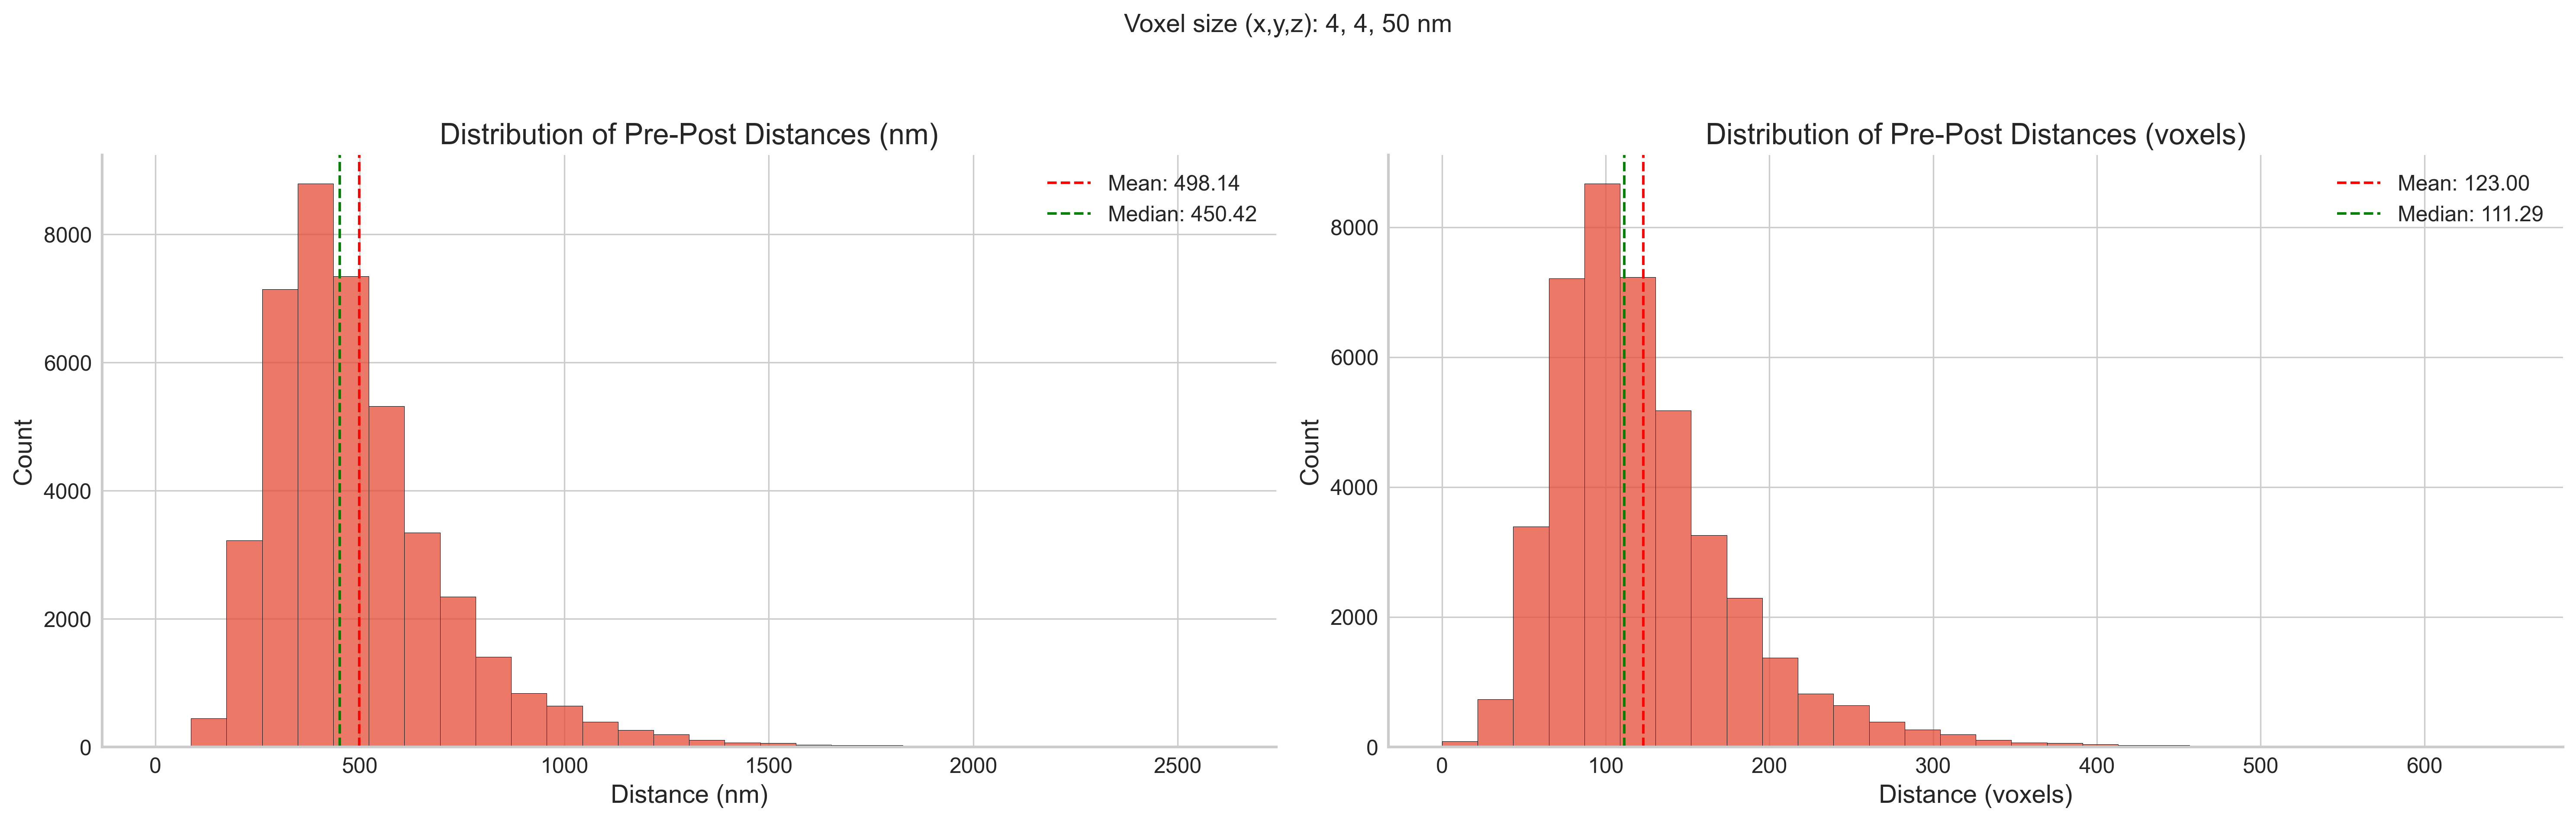

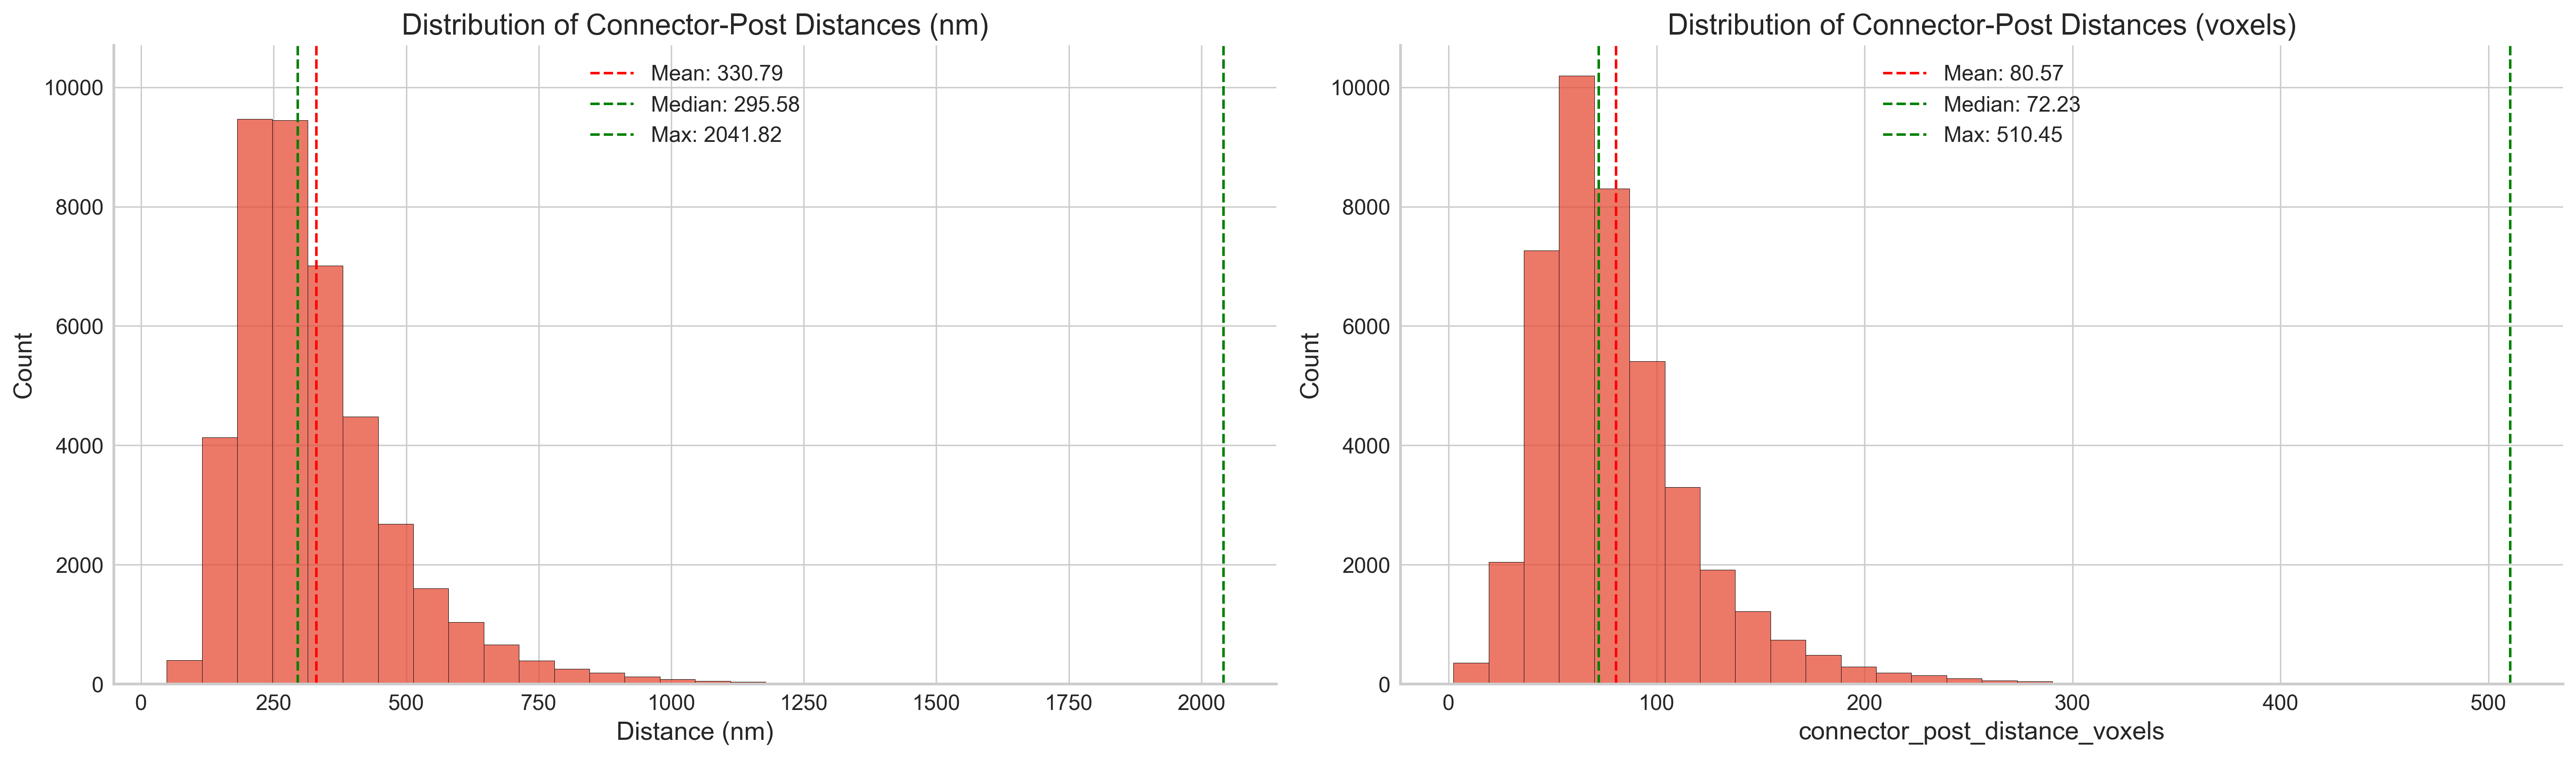

Total points in nm space: 42115
Total points in voxel space: 42115

Sum of histogram counts in nm space: 42115
Sum of histogram counts in voxel space: 42115


In [126]:
results_output_dir = "/Volumes/SamiaSan/PhD_extras/figs/synapse_analysis_plots/seymour"
os.makedirs(results_output_dir, exist_ok=True)

# Define voxel size
voxel_size = {'x': 4, 'y': 4, 'z': 50}

# Calculate distances in physical space (already in nm) and voxel space
df['pre_post_distance_nm'] = ((df['pre_x'] - df['post_x'])**2 + 
                             (df['pre_y'] - df['post_y'])**2 + 
                             (df['pre_z'] - df['post_z'])**2)**0.5

df['pre_post_distance_voxels'] = ((df['pre_x']/voxel_size['x'] - df['post_x']/voxel_size['x'])**2 + 
                                 (df['pre_y']/voxel_size['y'] - df['post_y']/voxel_size['y'])**2 + 
                                 (df['pre_z']/voxel_size['z'] - df['post_z']/voxel_size['z'])**2)**0.5

# Create side-by-side plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))

# Physical space plot (nm)
sns.histplot(df['pre_post_distance_nm'], kde=False, bins=30, ax=ax1)
ax1.axvline(df['pre_post_distance_nm'].mean(), color='r', linestyle='--', 
            label=f'Mean: {df["pre_post_distance_nm"].mean():.2f}')
ax1.axvline(df['pre_post_distance_nm'].median(), color='g', linestyle='--', 
            label=f'Median: {df["pre_post_distance_nm"].median():.2f}')
ax1.set_title('Distribution of Pre-Post Distances (nm)')
ax1.set_xlabel('Distance (nm)')
ax1.set_ylabel('Count')
ax1.legend()

# Voxel space plot
sns.histplot(df['pre_post_distance_voxels'], kde=False, bins=30, ax=ax2)
ax2.axvline(df['pre_post_distance_voxels'].mean(), color='r', linestyle='--', 
            label=f'Mean: {df["pre_post_distance_voxels"].mean():.2f}')
ax2.axvline(df['pre_post_distance_voxels'].median(), color='g', linestyle='--', 
            label=f'Median: {df["pre_post_distance_voxels"].median():.2f}')
ax2.set_title('Distribution of Pre-Post Distances (voxels)')
ax2.set_xlabel('Distance (voxels)')
ax2.set_ylabel('Count')
ax2.legend()

# Add voxel size information
fig.suptitle(f'Voxel size (x,y,z): {voxel_size["x"]}, {voxel_size["y"]}, {voxel_size["z"]} nm', 
             y=1.05, fontsize=14)

plt.tight_layout()
sns.despine()
plt.show()
fig.savefig(os.path.join(results_output_dir,'pre_post_distance_distributions_both_spaces.svg'))

# Same for connector-post distances
df['connector_post_distance_nm'] = ((df['connector_x'] - df['post_x'])**2 + 
                                  (df['connector_y'] - df['post_y'])**2 + 
                                  (df['connector_z'] - df['post_z'])**2)**0.5

df['connector_post_distance_voxels'] = ((df['connector_x']/voxel_size['x'] - df['post_x']/voxel_size['x'])**2 + 
                                      (df['connector_y']/voxel_size['y'] - df['post_y']/voxel_size['y'])**2 + 
                                      (df['connector_z']/voxel_size['z'] - df['post_z']/voxel_size['z'])**2)**0.5

# Create side-by-side plots for connector-post distances
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))

# Physical space plot (nm)
sns.histplot(df['connector_post_distance_nm'], kde=False,  bins=30, ax=ax1) 
ax1.axvline(df['connector_post_distance_nm'].mean(), color='r', linestyle='--', 
            label=f'Mean: {df["connector_post_distance_nm"].mean():.2f}')
ax1.axvline(df['connector_post_distance_nm'].median(), color='g', linestyle='--', 
            label=f'Median: {df["connector_post_distance_nm"].median():.2f}')
ax1.axvline(df['connector_post_distance_nm'].max(), color='g', linestyle='--', 
            label=f'Max: {df["connector_post_distance_nm"].max():.2f}')
ax1.set_title('Distribution of Connector-Post Distances (nm)')
ax1.set_xlabel('Distance (nm)')
ax1.set_ylabel('Count')
ax1.legend()

# Voxel space plot
sns.histplot(df['connector_post_distance_voxels'], kde=False, bins=30, ax=ax2) 
ax2.axvline(df['connector_post_distance_voxels'].mean(), color='r', linestyle='--', 
            label=f'Mean: {df["connector_post_distance_voxels"].mean():.2f}')
ax2.axvline(df['connector_post_distance_voxels'].median(), color='g', linestyle='--', 
            label=f'Median: {df["connector_post_distance_voxels"].median():.2f}')
ax2.axvline(df['connector_post_distance_voxels'].max(), color='g', linestyle='--', 
            label=f'Max: {df["connector_post_distance_voxels"].max():.2f}')
ax2.set_title('Distribution of Connector-Post Distances (voxels)')
# Ensure both plots have the same y-axis bounds
ax1.set_ylim(0, max(ax1.get_ylim()[1], ax2.get_ylim()[1]))
ax2.set_ylim(0, max(ax1.get_ylim()[1], ax2.get_ylim()[1]))
ax2.legend()

plt.tight_layout()
sns.despine()
plt.show()
fig.savefig(os.path.join(results_output_dir,'connector_post_distance_distributions_both_spaces.svg'))


# Verify total counts
print(f"Total points in nm space: {len(df['connector_post_distance_nm'])}")
print(f"Total points in voxel space: {len(df['connector_post_distance_voxels'])}")

# Check if the relative proportions are preserved
nm_hist, _ = np.histogram(df['connector_post_distance_nm'], bins=30)
voxel_hist, _ = np.histogram(df['connector_post_distance_voxels'], bins=30)
print(f"\nSum of histogram counts in nm space: {nm_hist.sum()}")
print(f"Sum of histogram counts in voxel space: {voxel_hist.sum()}")

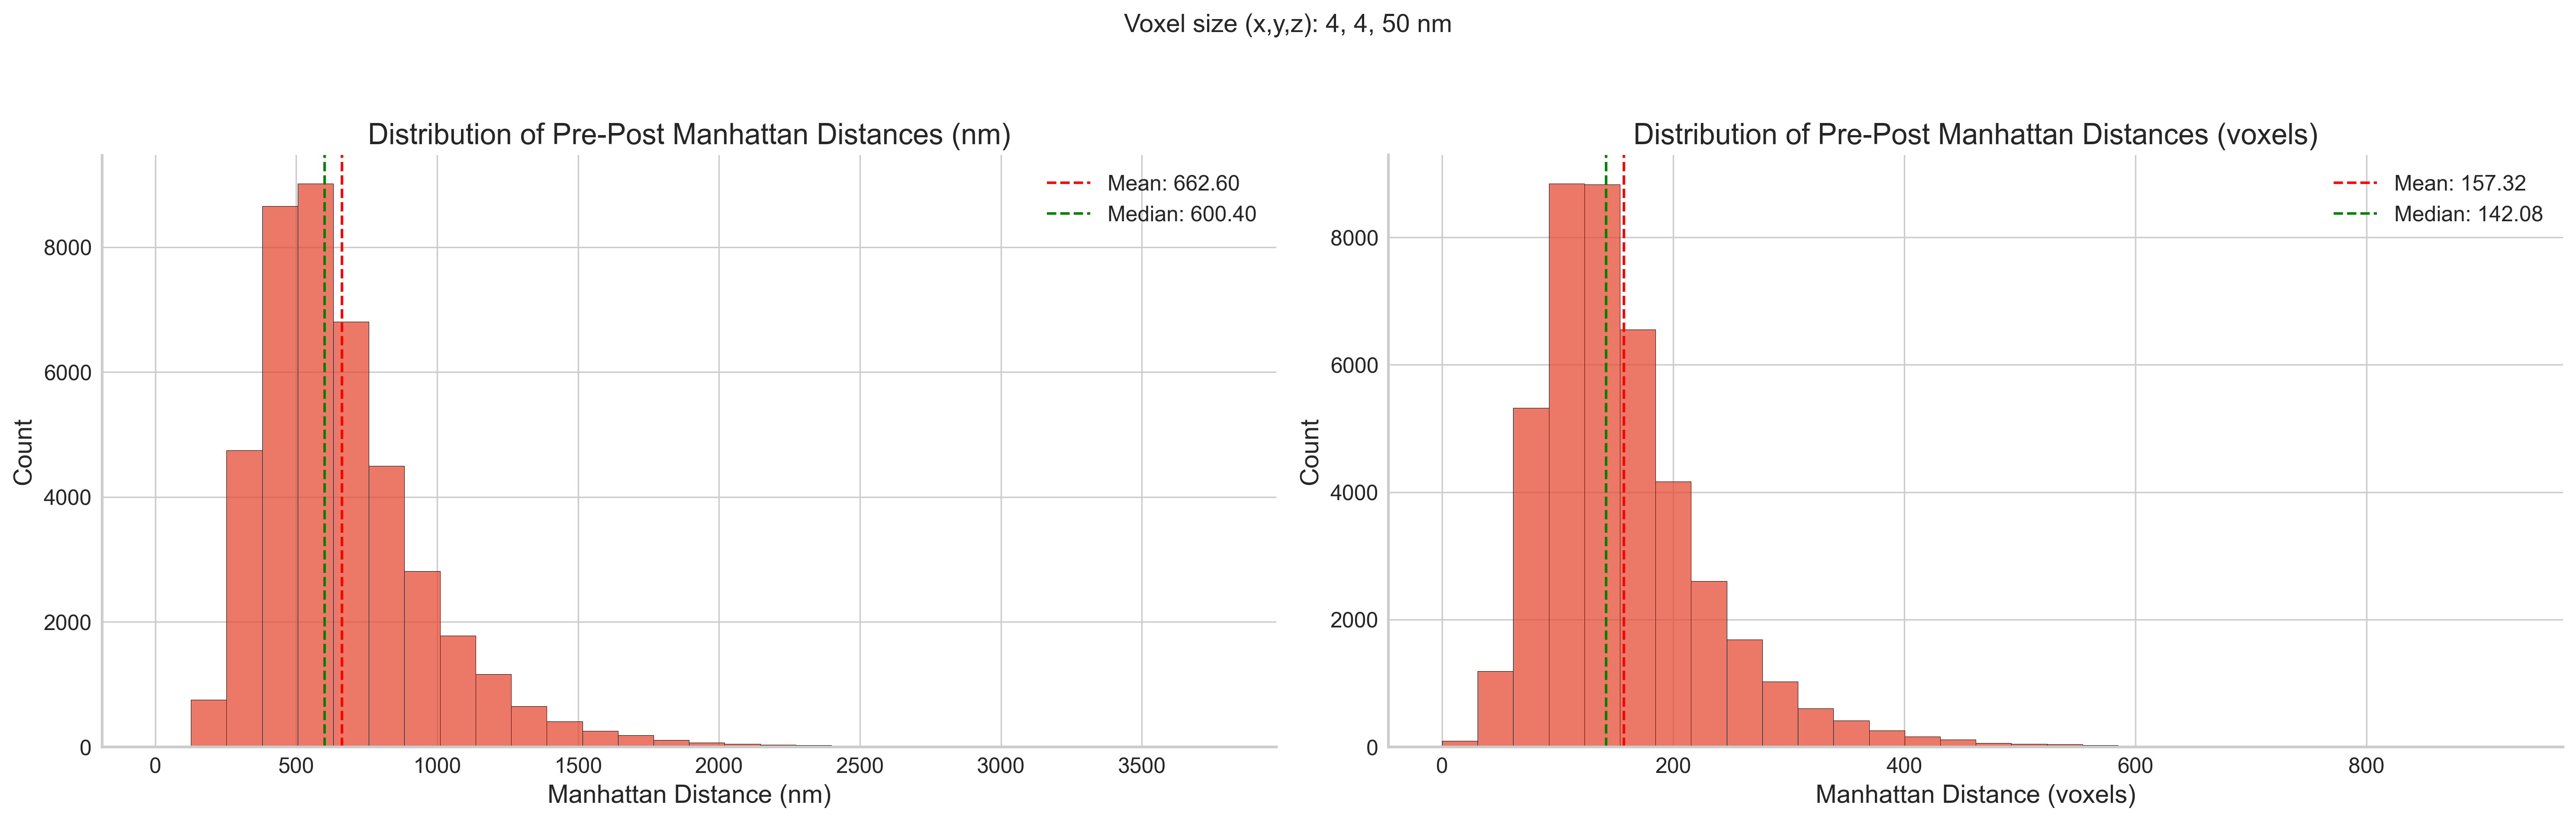

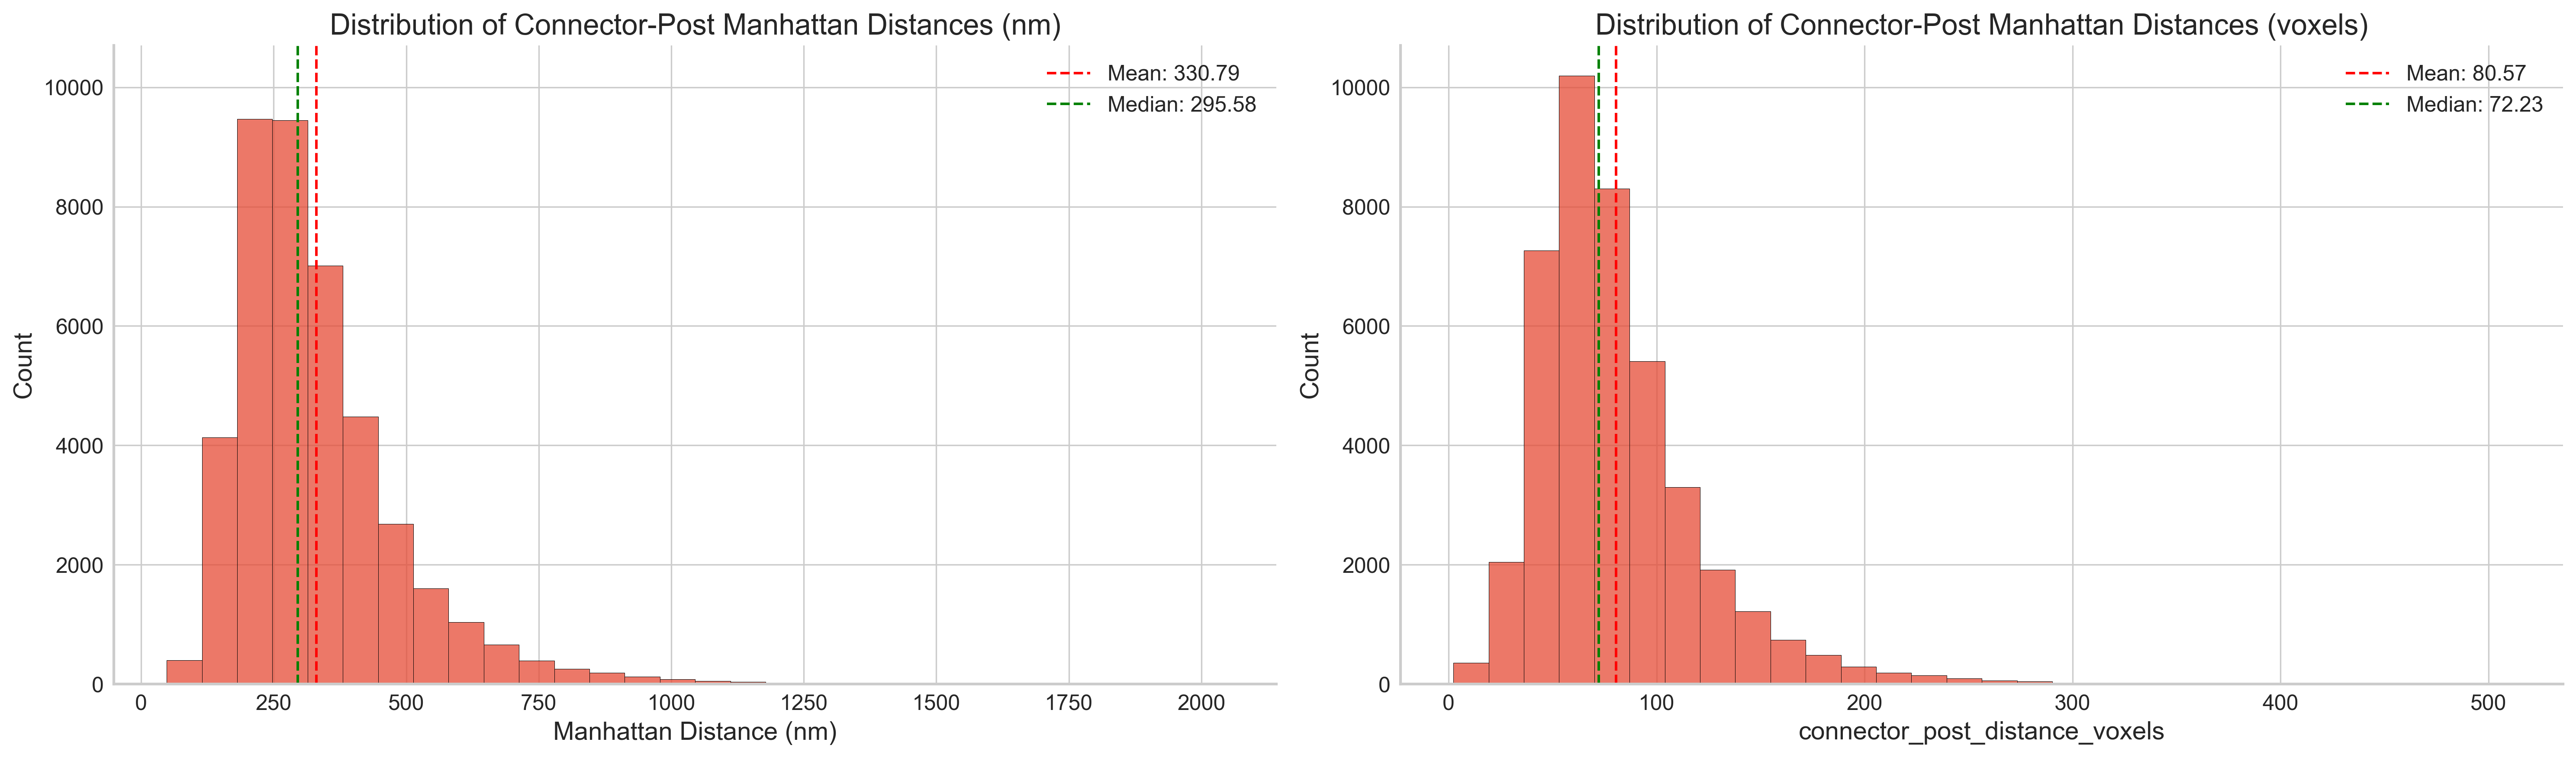

Total points in nm space: 42115
Total points in voxel space: 42115

Sum of histogram counts in nm space: 42115
Sum of histogram counts in voxel space: 42115


In [114]:
# calculate manhattan distances
results_output_dir = "/Volumes/SamiaSan/PhD_extras/figs/synapse_analysis_plots/seymour"
os.makedirs(results_output_dir, exist_ok=True)

# Define voxel size
voxel_size = {'x': 4, 'y': 4, 'z': 50}

# Calculate Manhattan distances in physical space (nm)
df['pre_post_distance_nm'] = (np.abs(df['pre_x'] - df['post_x']) + 
                             np.abs(df['pre_y'] - df['post_y']) + 
                             np.abs(df['pre_z'] - df['post_z']))

# Calculate Manhattan distances in voxel space
df['pre_post_distance_voxels'] = (np.abs(df['pre_x']/voxel_size['x'] - df['post_x']/voxel_size['x']) + 
                                 np.abs(df['pre_y']/voxel_size['y'] - df['post_y']/voxel_size['y']) + 
                                 np.abs(df['pre_z']/voxel_size['z'] - df['post_z']/voxel_size['z']))
# Create side-by-side plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))

# Physical space plot (nm)
sns.histplot(df['pre_post_distance_nm'], kde=False, bins=30, ax=ax1)
ax1.axvline(df['pre_post_distance_nm'].mean(), color='r', linestyle='--', 
            label=f'Mean: {df["pre_post_distance_nm"].mean():.2f}')
ax1.axvline(df['pre_post_distance_nm'].median(), color='g', linestyle='--', 
            label=f'Median: {df["pre_post_distance_nm"].median():.2f}')
ax1.set_title('Distribution of Pre-Post Manhattan Distances (nm)')
ax1.set_xlabel('Manhattan Distance (nm)')
ax1.set_ylabel('Count')
ax1.legend()

# Voxel space plot
sns.histplot(df['pre_post_distance_voxels'], kde=False, bins=30, ax=ax2)
ax2.axvline(df['pre_post_distance_voxels'].mean(), color='r', linestyle='--', 
            label=f'Mean: {df["pre_post_distance_voxels"].mean():.2f}')
ax2.axvline(df['pre_post_distance_voxels'].median(), color='g', linestyle='--', 
            label=f'Median: {df["pre_post_distance_voxels"].median():.2f}')
ax2.set_title('Distribution of Pre-Post Manhattan Distances (voxels)')
ax2.set_xlabel('Manhattan Distance (voxels)')
ax2.set_ylabel('Count')
ax2.legend()

# Add voxel size information
fig.suptitle(f'Voxel size (x,y,z): {voxel_size["x"]}, {voxel_size["y"]}, {voxel_size["z"]} nm', 
             y=1.05, fontsize=14)

plt.tight_layout()
sns.despine()
plt.show()
fig.savefig(os.path.join(results_output_dir,'pre_post_distance_distributions_both_spaces.svg'))

# Same for connector-post distances
# Calculate Manhattan distances in physical space (nm)
df['pre_post_distance_nm'] = (np.abs(df['connector_x'] - df['post_x']) + 
                             np.abs(df['connector_y'] - df['post_y']) + 
                             np.abs(df['connector_z'] - df['post_z']))

# Calculate Manhattan distances in voxel space
df['pre_post_distance_voxels'] = (np.abs(df['connector_x']/voxel_size['x'] - df['post_x']/voxel_size['x']) + 
                                 np.abs(df['connector_y']/voxel_size['y'] - df['post_y']/voxel_size['y']) + 
                                 np.abs(df['connector_z']/voxel_size['z'] - df['post_z']/voxel_size['z']))
# Create side-by-side plots for connector-post distances
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))

# Physical space plot (nm)
sns.histplot(df['connector_post_distance_nm'], kde=False,  bins=30, ax=ax1) 
ax1.axvline(df['connector_post_distance_nm'].mean(), color='r', linestyle='--', 
            label=f'Mean: {df["connector_post_distance_nm"].mean():.2f}')
ax1.axvline(df['connector_post_distance_nm'].median(), color='g', linestyle='--', 
            label=f'Median: {df["connector_post_distance_nm"].median():.2f}')
ax1.set_title('Distribution of Connector-Post Manhattan Distances (nm)')
ax1.set_xlabel('Manhattan Distance (nm)')
ax1.set_ylabel('Count')
ax1.legend()

# Voxel space plot
sns.histplot(df['connector_post_distance_voxels'], kde=False, bins=30, ax=ax2) 
ax2.axvline(df['connector_post_distance_voxels'].mean(), color='r', linestyle='--', 
            label=f'Mean: {df["connector_post_distance_voxels"].mean():.2f}')
ax2.axvline(df['connector_post_distance_voxels'].median(), color='g', linestyle='--', 
            label=f'Median: {df["connector_post_distance_voxels"].median():.2f}')
ax2.set_title('Distribution of Connector-Post Manhattan Distances (voxels)')
# Ensure both plots have the same y-axis bounds
ax1.set_ylim(0, max(ax1.get_ylim()[1], ax2.get_ylim()[1]))
ax2.set_ylim(0, max(ax1.get_ylim()[1], ax2.get_ylim()[1]))
ax2.legend()

plt.tight_layout()
sns.despine()
plt.show()
fig.savefig(os.path.join(results_output_dir,'connector_post_distance_distributions_both_spaces.svg'))


# Verify total counts
print(f"Total points in nm space: {len(df['connector_post_distance_nm'])}")
print(f"Total points in voxel space: {len(df['connector_post_distance_voxels'])}")

# Check if the relative proportions are preserved
nm_hist, _ = np.histogram(df['connector_post_distance_nm'], bins=30)
voxel_hist, _ = np.histogram(df['connector_post_distance_voxels'], bins=30)
print(f"\nSum of histogram counts in nm space: {nm_hist.sum()}")
print(f"Sum of histogram counts in voxel space: {voxel_hist.sum()}")